# **Project Title: Indian Premier League (IPL) Cricket Match Analysis 🏏**

## **Project Description**

This project analyzes ball-by-ball IPL match data to uncover patterns, strategies, and key performance indicators that lead to victory. The goal is to evaluate player and team impact, identify the statistical drivers of success, and build a foundation for predictive modeling of match outcomes based on the state of the game.

#
---

# **1.  Problem Definition & Objectives**

## **Problem Statement**

The Indian Premier League (IPL) is a professional Twenty20 cricket league in India, known for its explosive batting, strategic bowling, and thrilling finishes. While team composition and player form are crucial, several strategic factors and in-game events significantly influence the outcome of a match. This project aims to perform an in-depth analysis of ball-by-ball IPL match data to uncover the statistical drivers of success and identify key patterns that lead to victory.

The core objective of this analysis is to answer the question: **"What are the most significant statistical factors and strategies that contribute to winning an IPL match?"**

## **Objectives**

To achieve this, the project will focus on the following key objectives:

-  **Toss Analysis:** Determine the strategic impact of winning the toss and the subsequent decision to bat or field.

-  **Team Dominance:** Identify the most successful teams in IPL history based on win percentages and consistency.

-  **Player Performance:** Pinpoint the most impactful players by analyzing top run-scorers, leading wicket-takers, and 'Player of the Match' awards.

-  **Venue Impact:** Analyze if certain venues favor batting or bowling teams.

-  **Strategic Insights:** Translate the findings into data-driven recommendations for team strategy and auction decisions.

#
---

# **2.  Data Collection & Sources**

The analysis is based on two comprehensive datasets, which are publicly available on Kaggle and commonly used for IPL analysis. These datasets provide detailed ball-by-ball information for every IPL match from the inaugural 2008 season up to the 2024 season.

**1.**  **`matches.csv`**: This file contains match-level information. Each row represents a single match and includes details such as:
    
- Match ID, season, date, and venue.

- The two competing teams.

- Toss winner and their decision (to bat or field).

- The winner of the match and the margin of victory.

- Player of the match and the umpires.

**2.**  **`deliveries.csv`**: This file contains ball-by-ball data for every match. Each row represents one ball bowled and includes details like:

- Match ID to link with the `matches.csv` file.

- Inning, over, and ball number.

- The batting and bowling teams.

- The batsman on strike, the non-striker, and the bowler.

- Runs scored, extras, total runs and wickets taken on that delivery.

The granularity of the ball-by-ball data is the foundation of this project, allowing for deep and specific analysis through visualizations that would not be possible with simple match summaries.

#
---

# **Setting Up the Basic Needs**

## **Install Necessary Libraries**

Open the Terminal in VS Code and run this command:

```
pip install -r requirements.txt
```

## **Import All Necessary Libraries for the Analysis**

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

print("Libraries imported successfully.")

Libraries imported successfully.


#
---

# **3.  Data Cleaning & Preparation**

**The first step in our analysis is to load the data and ensure it is clean, consistent, and ready for exploration. This process, also known as data preprocessing, is crucial for accurate results.**

**Before analysis, the data must be cleaned and prepared. This involves:**

- **Loading and Inspecting the datasets.**

- **Handling missing values (e.g., filling in missing 'city' information).**

- **Correcting data types (e.g., converting 'date' from text to a real date).**

- **Standardizing team names that have changed over the years (e.g., 'Delhi Daredevils' to 'Delhi Capitals').**

- **Dropping unnecessary rows and columns (e.g., method, umpire1, etc.).**

- **Merge the dataframes for combined analysis.**

- **Saving the cleaned & merged dataframes for future use.**

## **--- 3.1 : Load the Datasets ---**

In [3]:
# Load the datasets from the 'sample_datasets' folder into pandas DataFrames
# A DataFrame is like a table, which is a great way to view and manipulate data

try:
    matches_df = pd.read_csv('../sample_datasets/matches.csv')
    deliveries_df = pd.read_csv('../sample_datasets/deliveries.csv')
    print("Datasets loaded successfully.")
except FileNotFoundError:
    print("Error: Make sure 'matches.csv' and 'deliveries.csv' are in the '../sample_datasets/' folder.")

Datasets loaded successfully.


In [4]:
# Display the first 5 rows of the matches DataFrame to get a quick look at the data

print("--- Matches DataFrame: First 5 Rows ---")
display(matches_df.head())

--- Matches DataFrame: First 5 Rows ---


,id,season,city,date,match_type,player_of_match,venue,team1,team2,toss_winner,toss_decision,winner,result,result_margin,target_runs,target_overs,super_over,method,umpire1,umpire2
0,335982,2007/08,Bangalore,2008-04-18,League,BB McCullum,M Chinnaswamy Stadium,Royal Challengers Bangalore,Kolkata Knight Riders,Royal Challengers Bangalore,field,Kolkata Knight Riders,runs,140.0,223.0,20.0,N,NaN,Asad Rauf,RE Koertzen
1,335983,2007/08,Chandigarh,2008-04-19,League,MEK Hussey,"Punjab Cricket Association Stadium, Mohali",Kings XI Punjab,Chennai Super Kings,Chennai Super Kings,bat,Chennai Super Kings,runs,33.0,241.0,20.0,N,NaN,MR Benson,SL Shastri
2,335984,2007/08,Delhi,2008-04-19,League,MF Maharoof,Feroz Shah Kotla,Delhi Daredevils,Rajasthan Royals,Rajasthan Royals,bat,Delhi Daredevils,wickets,9.0,130.0,20.0,N,NaN,Aleem Dar,GA Pratapkumar
3,335985,2007/08,Mumbai,2008-04-20,League,MV Boucher,Wankhede Stadium,Mumbai Indians,Royal Challengers Bangalore,Mumbai Indians,bat,Royal Challengers Bangalore,wickets,5.0,166.0,20.0,N,NaN,SJ Davis,DJ Harper
4,335986,2007/08,Kolkata,2008-04-20,League,DJ Hussey,Eden Gardens,Kolkata Knight Riders,Deccan Chargers,Deccan Chargers,bat,Kolkata Knight Riders,wickets,5.0,111.0,20.0,N,NaN,BF Bowden,K Hariharan


In [5]:
# Display the first 5 rows of the deliveries DataFrame

print("--- Deliveries DataFrame: First 5 Rows ---")
display(deliveries_df.head())

--- Deliveries DataFrame: First 5 Rows ---


,match_id,inning,batting_team,bowling_team,over,ball,batter,bowler,non_striker,batsman_runs,extra_runs,total_runs,extras_type,is_wicket,player_dismissed,dismissal_kind,fielder
0,335982,1,Kolkata Knight Riders,Royal Challengers Bangalore,0,1,SC Ganguly,P Kumar,BB McCullum,0,1,1,legbyes,0,NaN,NaN,NaN
1,335982,1,Kolkata Knight Riders,Royal Challengers Bangalore,0,2,BB McCullum,P Kumar,SC Ganguly,0,0,0,NaN,0,NaN,NaN,NaN
2,335982,1,Kolkata Knight Riders,Royal Challengers Bangalore,0,3,BB McCullum,P Kumar,SC Ganguly,0,1,1,wides,0,NaN,NaN,NaN
3,335982,1,Kolkata Knight Riders,Royal Challengers Bangalore,0,4,BB McCullum,P Kumar,SC Ganguly,0,0,0,NaN,0,NaN,NaN,NaN
4,335982,1,Kolkata Knight Riders,Royal Challengers Bangalore,0,5,BB McCullum,P Kumar,SC Ganguly,0,0,0,NaN,0,NaN,NaN,NaN


## **--- 3.2 : Initial Data Inspection ---**

In [6]:
# --- Initial Inspection of matches_df ---

print("--- Matches DataFrame Info ---")
matches_df.info()

print("--- Missing Values in Matches DataFrame ---")
print(matches_df.isnull().sum())

--- Matches DataFrame Info ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1095 entries, 0 to 1094
Data columns (total 20 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   id               1095 non-null   int64  
 1   season           1095 non-null   object 
 2   city             1044 non-null   object 
 3   date             1095 non-null   object 
 4   match_type       1095 non-null   object 
 5   player_of_match  1090 non-null   object 
 6   venue            1095 non-null   object 
 7   team1            1095 non-null   object 
 8   team2            1095 non-null   object 
 9   toss_winner      1095 non-null   object 
 10  toss_decision    1095 non-null   object 
 11  winner           1090 non-null   object 
 12  result           1095 non-null   object 
 13  result_margin    1076 non-null   float64
 14  target_runs      1092 non-null   float64
 15  target_overs     1092 non-null   float64
 16  super_over       1095 non-nul

In [7]:
# --- Initial Inspection of deliveries_df ---

print("--- Deliveries DataFrame Info ---")
deliveries_df.info()

print("--- Missing Values in Deliveries DataFrame ---")
print(deliveries_df.isnull().sum())

--- Deliveries DataFrame Info ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 260920 entries, 0 to 260919
Data columns (total 17 columns):
 #   Column            Non-Null Count   Dtype 
---  ------            --------------   ----- 
 0   match_id          260920 non-null  int64 
 1   inning            260920 non-null  int64 
 2   batting_team      260920 non-null  object
 3   bowling_team      260920 non-null  object
 4   over              260920 non-null  int64 
 5   ball              260920 non-null  int64 
 6   batter            260920 non-null  object
 7   bowler            260920 non-null  object
 8   non_striker       260920 non-null  object
 9   batsman_runs      260920 non-null  int64 
 10  extra_runs        260920 non-null  int64 
 11  total_runs        260920 non-null  int64 
 12  extras_type       14125 non-null   object
 13  is_wicket         260920 non-null  int64 
 14  player_dismissed  12950 non-null   object
 15  dismissal_kind    12950 non-null   object
 16  fiel

## **--- 3.3 : Handling Missing Values ---**

In [8]:
# Check which venues have a missing city value

print("Venues with missing City information:")
print(matches_df[matches_df['city'].isnull()]['venue'].unique())
print("-" * 100) # A separator line

Venues with missing City information:
['Sharjah Cricket Stadium' 'Dubai International Cricket Stadium']
----------------------------------------------------------------------------------------------------


In [10]:
# From the output, we see venues like 'Dubai International Cricket Stadium' and 'Sharjah Cricket Stadium' have missing city values. 
# Let's fill the missing cities based on the venue.
# We'll use the venue name to determine the correct city.

# For instance, Dubai International Cricket Stadium is in Dubai.
matches_df.loc[matches_df['venue'] == 'Dubai International Cricket Stadium', 'city'] = 'Dubai'

# For instance, Sharjah Cricket Stadium is in Sharjah.
matches_df.loc[matches_df['venue'] == 'Sharjah Cricket Stadium', 'city'] = 'Sharjah'

In [11]:
# Let's check the remaining missing values for city.

print("Missing city values remaining:")
print(matches_df['city'].isnull().sum())

Missing city values remaining:
0


## **--- 3.4 : Correcting Data Types ---**

In [12]:
# Convert the 'date' column to a proper datetime format

matches_df['date'] = pd.to_datetime(matches_df['date'])

In [13]:
# The 'season' column is in a 'YYYY/YY' format (e.g., 2007/08). Let's simplify it to just the starting year (e.g., 2008).
# We'll extract the year from our new 'date' column, which is more reliable.

matches_df['season'] = matches_df['date'].dt.year

In [14]:
# Let's check the data types again to confirm our changes

print("--- Corrected Data Types in Matches DataFrame ---")
matches_df.info()

--- Corrected Data Types in Matches DataFrame ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1095 entries, 0 to 1094
Data columns (total 20 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   id               1095 non-null   int64         
 1   season           1095 non-null   int32         
 2   city             1095 non-null   object        
 3   date             1095 non-null   datetime64[ns]
 4   match_type       1095 non-null   object        
 5   player_of_match  1090 non-null   object        
 6   venue            1095 non-null   object        
 7   team1            1095 non-null   object        
 8   team2            1095 non-null   object        
 9   toss_winner      1095 non-null   object        
 10  toss_decision    1095 non-null   object        
 11  winner           1090 non-null   object        
 12  result           1095 non-null   object        
 13  result_margin    1076 non-null   float64   

In [15]:
# Let's look at the first few rows to see our changes

display(matches_df.head())

,id,season,city,date,match_type,player_of_match,venue,team1,team2,toss_winner,toss_decision,winner,result,result_margin,target_runs,target_overs,super_over,method,umpire1,umpire2
0,335982,2008,Bangalore,2008-04-18,League,BB McCullum,M Chinnaswamy Stadium,Royal Challengers Bangalore,Kolkata Knight Riders,Royal Challengers Bangalore,field,Kolkata Knight Riders,runs,140.0,223.0,20.0,N,NaN,Asad Rauf,RE Koertzen
1,335983,2008,Chandigarh,2008-04-19,League,MEK Hussey,"Punjab Cricket Association Stadium, Mohali",Kings XI Punjab,Chennai Super Kings,Chennai Super Kings,bat,Chennai Super Kings,runs,33.0,241.0,20.0,N,NaN,MR Benson,SL Shastri
2,335984,2008,Delhi,2008-04-19,League,MF Maharoof,Feroz Shah Kotla,Delhi Daredevils,Rajasthan Royals,Rajasthan Royals,bat,Delhi Daredevils,wickets,9.0,130.0,20.0,N,NaN,Aleem Dar,GA Pratapkumar
3,335985,2008,Mumbai,2008-04-20,League,MV Boucher,Wankhede Stadium,Mumbai Indians,Royal Challengers Bangalore,Mumbai Indians,bat,Royal Challengers Bangalore,wickets,5.0,166.0,20.0,N,NaN,SJ Davis,DJ Harper
4,335986,2008,Kolkata,2008-04-20,League,DJ Hussey,Eden Gardens,Kolkata Knight Riders,Deccan Chargers,Deccan Chargers,bat,Kolkata Knight Riders,wickets,5.0,111.0,20.0,N,NaN,BF Bowden,K Hariharan


## **--- 3.5 : Standardizing Team Names ---**

In [16]:
# Create a dictionary to map old team names to their new names

team_name_mapping = {
    'Delhi Daredevils': 'Delhi Capitals',
    'Deccan Chargers': 'Sunrisers Hyderabad',
    'Pune Warriors': 'Rising Pune Supergiant',
    'Gujarat Lions': 'Gujarat Titans'
    # Note: 'Rising Pune Supergiant' is used for both Pune teams for simplicity.
}

In [17]:
# Apply this mapping to all columns that contain team names

matches_df['team1'] = matches_df['team1'].replace(team_name_mapping)
matches_df['team2'] = matches_df['team2'].replace(team_name_mapping)
matches_df['toss_winner'] = matches_df['toss_winner'].replace(team_name_mapping)
matches_df['winner'] = matches_df['winner'].replace(team_name_mapping)


# Let's do the same for the deliveries dataframe

deliveries_df['batting_team'] = deliveries_df['batting_team'].replace(team_name_mapping)
deliveries_df['bowling_team'] = deliveries_df['bowling_team'].replace(team_name_mapping)


print("Team names have been standardized across both datasets.")

Team names have been standardized across both datasets.


## **--- 3.6 : Dropping Unnecessary Rows & Columns ---**

In [18]:
# The 'method' column is mostly empty and related to D/L method, which is rare.
# 'umpire1' and 'umpire2' are not needed for our current analysis objectives.
# The 'id' column is unique to each match, but we can use the DataFrame's index if needed. Let's drop it to keep things clean.

columns_to_drop = ['method', 'umpire1', 'umpire2']
matches_df.drop(columns=columns_to_drop, inplace=True)

# Explanation of parameters:
# 'columns': The list of columns we want to remove.
# 'inplace=True': This modifies the DataFrame directly, without needing to assign it back (e.g., matches_df = ...).


In [19]:
# Remove matches with no result from analysis

matches_df.dropna(subset=['winner'], inplace=True)

print(f"Total Matches in DataFrame after cleaning: {matches_df.shape[0]}")

Total Matches in DataFrame after cleaning: 1090


## **--- 3.7 : Final Verification ---**

In [20]:
# Let's run .info() again to confirm our changes.
# We expect to see:
# - More non-null values in the 'city' column.
# - The dropped columns ('method', 'umpire1', 'umpire2') should be gone.
# - The 'date' column's Dtype should now be 'datetime64[ns]'.

print("Summary of the CLEANED Matches Dataset:")
matches_df.info()

Summary of the CLEANED Matches Dataset:
<class 'pandas.core.frame.DataFrame'>
Index: 1090 entries, 0 to 1094
Data columns (total 17 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   id               1090 non-null   int64         
 1   season           1090 non-null   int32         
 2   city             1090 non-null   object        
 3   date             1090 non-null   datetime64[ns]
 4   match_type       1090 non-null   object        
 5   player_of_match  1090 non-null   object        
 6   venue            1090 non-null   object        
 7   team1            1090 non-null   object        
 8   team2            1090 non-null   object        
 9   toss_winner      1090 non-null   object        
 10  toss_decision    1090 non-null   object        
 11  winner           1090 non-null   object        
 12  result           1090 non-null   object        
 13  result_margin    1076 non-null   float64       
 14  targe

In [21]:
# Let's also check the missing values again

print("Missing values in the CLEANED matches dataset:")
matches_df.isnull().sum()

Missing values in the CLEANED matches dataset:


id                  0
season              0
city                0
date                0
match_type          0
player_of_match     0
venue               0
team1               0
team2               0
toss_winner         0
toss_decision       0
winner              0
result              0
result_margin      14
target_runs         0
target_overs        0
super_over          0
dtype: int64

In [22]:
print("Data cleaning and preparation complete.")

Data cleaning and preparation complete.


## **--- 3.8 : Merge the Cleaned Datasets ---**

In [23]:
# Merge the two dataframes for combined analysis

merged_df = pd.merge(deliveries_df, matches_df, left_on='match_id', right_on='id')
print("Datasets merged successfully for combined analysis.")

Datasets merged successfully for combined analysis.


## **--- 3.9 : Save the Cleaned Datasets ---**

In [24]:
# Create the 'cleaned_datasets' directory if it doesn't exist

cleaned_data_dir = '../cleaned_datasets'
if not os.path.exists(cleaned_data_dir):
    os.makedirs(cleaned_data_dir)

In [25]:
# Save the cleaned dataframes to new CSV files

matches_df.to_csv(os.path.join(cleaned_data_dir, 'matches_cleaned.csv'), index=False)
deliveries_df.to_csv(os.path.join(cleaned_data_dir, 'deliveries_cleaned.csv'), index=False)
merged_df.to_csv(os.path.join(cleaned_data_dir, 'merged_ipl_datasets.csv'), index=False)

print("Cleaned datasets have been saved successfully to the 'cleaned_datasets' folder.")

Cleaned datasets have been saved successfully to the 'cleaned_datasets' folder.


#
---

# **4.  Data Exploration & Summarization**

**With our cleaned data, we can now explore it to answer key questions and summarize important statistics. This phase is about understanding the stories hidden within the data.**

## **--- 4.1 : Overall Match Statistics ---**

In [26]:
# Count the total number of matches played

total_matches = len(matches_df)
print(f"Total Matches Played: {total_matches}")

Total Matches Played: 1090


In [27]:
# Count the total number of seasons and give the list of seasons

total_seasons = len(matches_df['season'].unique())
print(f"Total Seasons: {total_seasons}")
list_of_seasons = matches_df['season'].unique()
print(f"List of Seasons: {list_of_seasons}")

Total Seasons: 17
List of Seasons: [2008 2009 2010 2011 2012 2013 2014 2015 2016 2017 2018 2019 2020 2021
 2022 2023 2024]


In [28]:
# Count the number of matches played in each season

matches_per_season = matches_df['season'].value_counts().sort_index()
print("Number of Matches Played Per Season:")
print(matches_per_season)

Number of Matches Played Per Season:
season
2008    58
2009    57
2010    60
2011    72
2012    74
2013    76
2014    60
2015    57
2016    60
2017    59
2018    60
2019    59
2020    60
2021    60
2022    74
2023    73
2024    71
Name: count, dtype: int64


## **--- 4.2 : Toss Analysis -> Win Percentage ---**

In [29]:
# Calculate the number of matches where the team winning the toss also won the match
toss_win_match_win = np.sum(matches_df['toss_winner'] == matches_df['winner'])

total_matches = len(matches_df)

# Calculate the percentage of matches won by the toss winner
toss_win_percentage = (toss_win_match_win / total_matches) * 100

In [30]:
print(f"Total matches played: {total_matches}")
print(f"Number of times toss winner won the match: {toss_win_match_win}")
print(f"Win Percentage for Toss Winners: {toss_win_percentage:.2f}%")

Total matches played: 1090
Number of times toss winner won the match: 554
Win Percentage for Toss Winners: 50.83%


## **--- 4.3 : Toss Analysis -> Decision Percentage ---**

In [31]:
# Calculate the number of decisions made by teams after winning the toss

toss_decision_counts = matches_df['toss_decision'].value_counts()
print("Toss Decision Counts:")
print(toss_decision_counts)

Toss Decision Counts:
toss_decision
field    700
bat      390
Name: count, dtype: int64


In [33]:
# Calculate the percentage of each toss decision

toss_decision_percentage = (toss_decision_counts / toss_decision_counts.sum()) * 100
print("Toss Decision Percentage:")
print(toss_decision_percentage)

Toss Decision Percentage:
toss_decision
field    64.220183
bat      35.779817
Name: count, dtype: float64


## **--- 4.4 : Most Successful Teams (by Wins) ---**

In [34]:
# Count the number of wins for each team

team_wins = matches_df['winner'].value_counts()
print("Total Wins by Each Team:")
print(team_wins)

Total Wins by Each Team:
winner
Mumbai Indians                 144
Chennai Super Kings            138
Kolkata Knight Riders          131
Sunrisers Hyderabad            117
Royal Challengers Bangalore    116
Delhi Capitals                 115
Rajasthan Royals               112
Kings XI Punjab                 88
Gujarat Titans                  41
Punjab Kings                    24
Lucknow Super Giants            24
Rising Pune Supergiant          22
Royal Challengers Bengaluru      7
Kochi Tuskers Kerala             6
Rising Pune Supergiants          5
Name: count, dtype: int64


In [35]:
# Count the number most successful teams by wins

print("Most Successful Teams (by Wins):")
print(team_wins.head(5))

Most Successful Teams (by Wins):
winner
Mumbai Indians                 144
Chennai Super Kings            138
Kolkata Knight Riders          131
Sunrisers Hyderabad            117
Royal Challengers Bangalore    116
Name: count, dtype: int64


## **--- 4.5 : Top 5 'Player of the Match' Winners ----**

In [36]:
# Count the number of 'Player of the Match' awards won by each player

top_potm_players = matches_df['player_of_match'].value_counts()
print("Number 'Player of the Match' Awards Won by Each Player:")
print(top_potm_players)

Number 'Player of the Match' Awards Won by Each Player:
player_of_match
AB de Villiers    25
CH Gayle          22
RG Sharma         19
DA Warner         18
V Kohli           18
                  ..
A Manohar          1
Arshdeep Singh     1
DR Sams            1
MA Wood            1
JDP Oram           1
Name: count, Length: 291, dtype: int64


In [37]:
# Get the top 5 players with the most 'Player of the Match' awards

top_5_potm_players = top_potm_players.head(5)
print("Top 5 'Player of the Match' Winners:")
print(top_5_potm_players)

Top 5 'Player of the Match' Winners:
player_of_match
AB de Villiers    25
CH Gayle          22
RG Sharma         19
DA Warner         18
V Kohli           18
Name: count, dtype: int64


## **--- 4.6 : Top 5 Run Scorers (Batsmen) ----**

In [38]:
# Calculate the total runs scored by each batsman

top_run_scorers = deliveries_df.groupby('batter')['batsman_runs'].sum().sort_values(ascending=False)
print("Runs scored by each batsman:")
print(top_run_scorers)

Runs scored by each batsman:
batter
V Kohli           8014
S Dhawan          6769
RG Sharma         6630
DA Warner         6567
SK Raina          5536
                  ... 
KR Sen               0
L Ablish             0
KM Asif              0
Sunny Gupta          0
V Pratap Singh       0
Name: batsman_runs, Length: 673, dtype: int64


In [39]:
# Get the top 5 run scorers

top_5_run_scorers = top_run_scorers.head(5)
print("Top 5 Run Scorers:")
print(top_5_run_scorers)

Top 5 Run Scorers:
batter
V Kohli      8014
S Dhawan     6769
RG Sharma    6630
DA Warner    6567
SK Raina     5536
Name: batsman_runs, dtype: int64


## **--- 4.7 : Top 5 Wicket Takers (Bowlers) ----**

In [40]:
# In cricket, a bowler is credited with a wicket when they get a batsman out.
# We can identify wickets in the deliveries dataset by looking for rows where the 'dismissal_kind' column is not null.
# We exclude non-bowler wicket types

wicket_types_to_exclude = ['run out', 'retired hurt', 'obstructing the field']
wickets = merged_df[~merged_df['dismissal_kind'].isin(wicket_types_to_exclude) & (merged_df['is_wicket'] == 1)]

In [41]:
# Calculate the number of wickets taken by each bowler

top_wicket_takers = wickets.groupby('bowler')['is_wicket'].sum().sort_values(ascending=False)
print("Wickets taken by each bowler:")
print(top_wicket_takers)

Wickets taken by each bowler:
bowler
YS Chahal         202
PP Chawla         192
DJ Bravo          183
B Kumar           181
SP Narine         180
                 ... 
D Jansen            1
Shashank Singh      1
B Geeves            1
T Henderson         1
TP Sudhindra        1
Name: is_wicket, Length: 450, dtype: int64


In [42]:
# Get the top 5 wicket takers

top_5_wicket_takers = top_wicket_takers.head(5)
print("Top 5 Wicket Takers:")
print(top_5_wicket_takers)

Top 5 Wicket Takers:
bowler
YS Chahal    202
PP Chawla    192
DJ Bravo     183
B Kumar      181
SP Narine    180
Name: is_wicket, dtype: int64


## **--- 4.8 : Analysis of Victory Margins ---**

In [43]:
# Calculate the number of matches won by batting first (by runs)

wins_by_runs = matches_df[matches_df['result'] == 'runs']['winner'].count()
print(f"Number of matches won by batting first (by runs): {wins_by_runs}")

Number of matches won by batting first (by runs): 498


In [45]:
# Calculate the number of matches won by batting second or chasing (by wickets)

wins_by_wickets = matches_df[matches_df['result'] == 'wickets']['winner'].count()
print(f"Number of matches won by chasing (by wickets): {wins_by_wickets}")

Number of matches won by chasing (by wickets): 578


## **--- 4.9 : Most Frequent Match Venues ---**

In [46]:
# Calculate the number of matches played at each venue

venue_match_counts = matches_df['venue'].value_counts().sort_values(ascending=False)
print("Number of matches played at each venue:")
print(venue_match_counts)

Number of matches played at each venue:
venue
Eden Gardens                                                             77
Wankhede Stadium                                                         73
M Chinnaswamy Stadium                                                    63
Feroz Shah Kotla                                                         59
Rajiv Gandhi International Stadium, Uppal                                49
MA Chidambaram Stadium, Chepauk                                          48
Sawai Mansingh Stadium                                                   47
Dubai International Cricket Stadium                                      46
Wankhede Stadium, Mumbai                                                 45
Punjab Cricket Association Stadium, Mohali                               35
Sheikh Zayed Stadium                                                     29
Sharjah Cricket Stadium                                                  28
MA Chidambaram Stadium, Chepauk, Chennai  

In [47]:
# Get top 10 venues by number of matches played

top_10_venues = venue_match_counts.head(10)
print("Top 10 Venues by Number of Matches Played:")
print(top_10_venues)

Top 10 Venues by Number of Matches Played:
venue
Eden Gardens                                  77
Wankhede Stadium                              73
M Chinnaswamy Stadium                         63
Feroz Shah Kotla                              59
Rajiv Gandhi International Stadium, Uppal     49
MA Chidambaram Stadium, Chepauk               48
Sawai Mansingh Stadium                        47
Dubai International Cricket Stadium           46
Wankhede Stadium, Mumbai                      45
Punjab Cricket Association Stadium, Mohali    35
Name: count, dtype: int64


## **--- 4.10 : Number of 'Super Over' Matches ---**

In [48]:
# Calculate the total number of 'Super Over' matches played

super_over_matches = matches_df[matches_df['super_over'] == 'Y']['super_over'].count()
print(f"Total number of matches that went to a Super Over: {super_over_matches}")

Total number of matches that went to a Super Over: 14


#
---

# **5.  Data Visualization**

**Now, we will visualize our findings. A good visualization makes complex data easy to understand and tells a compelling story. We will create different designer-quality charts, complete with annotations, and save them to our `visualizations` folder.**

In [49]:
# --- Create the visualizations folder if it doesn't exist ---

viz_dir = '../visualizations'
if not os.path.exists(viz_dir):
    os.makedirs(viz_dir)

print("Setup complete. Ready for visualization.")

Setup complete. Ready for visualization.


In [50]:
# Set the default style and size for all our plots for a professional look

sns.set_style('darkgrid')
plt.style.use('dark_background')
plt.rcParams['figure.figsize'] = (20, 12)

## **--- 5.1 : Number of Matches Per Season (Bar Chart) ---**

C:\Users\Sahil Kesharwani\AppData\Local\Temp\ipykernel_20296\2256203014.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=matches_per_season.index, y=matches_per_season.values, ax=ax, palette='viridis')  # Create the bar plot


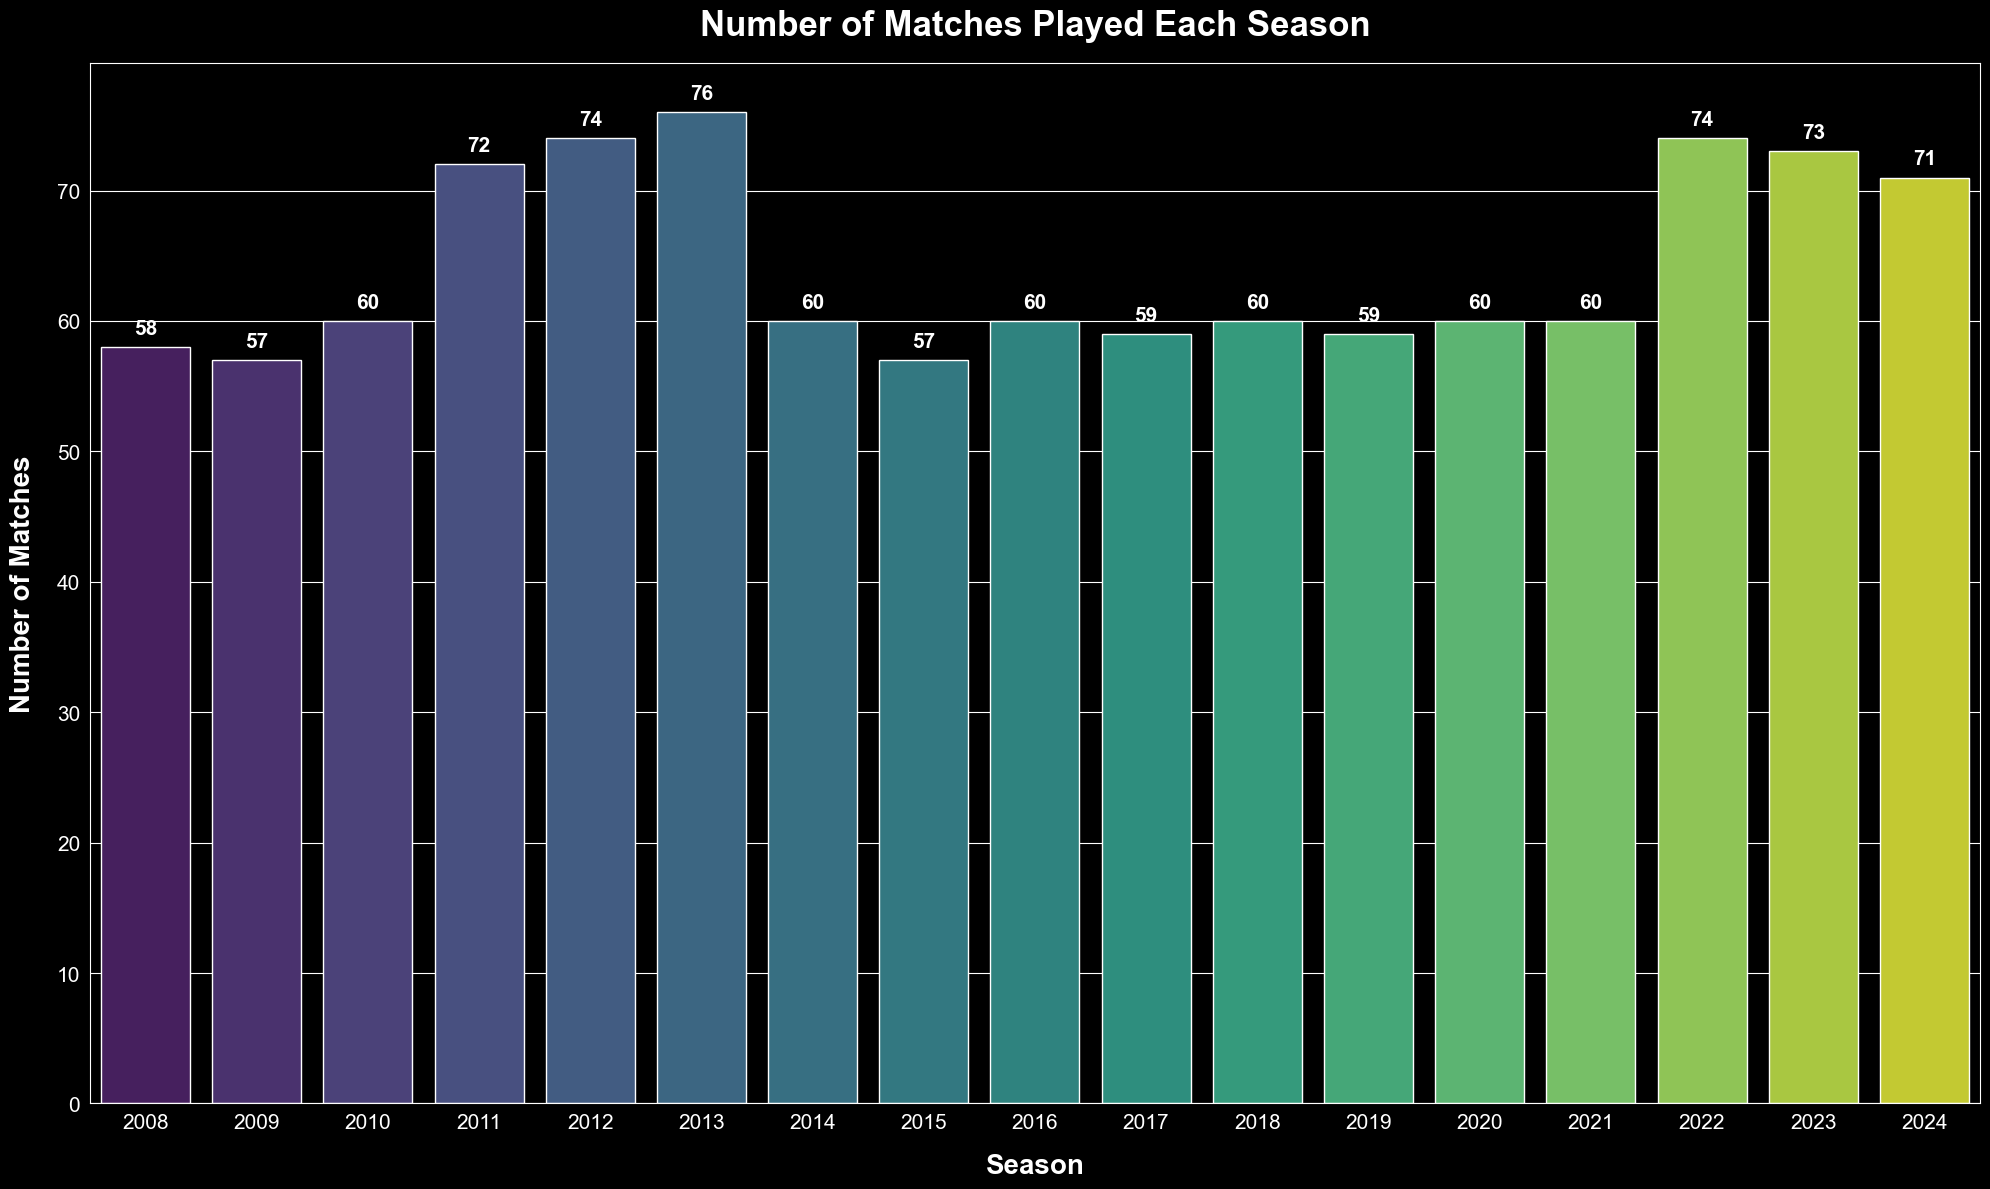

In [51]:
# Create a bar chart showing the number of matches played each season
# This visualization highlights the growth of the IPL over the years

fig, ax = plt.subplots(figsize=(20, 12))  # Create a new figure and axis for the plot
matches_per_season = matches_df['season'].value_counts().sort_index()  # Count matches per season and sort by season
sns.barplot(x=matches_per_season.index, y=matches_per_season.values, ax=ax, palette='viridis')  # Create the bar plot
ax.set_title('Number of Matches Played Each Season', fontsize=25, pad=20, weight='bold')  # Set the title with custom font size and padding
ax.set_xlabel('Season', fontsize=20, labelpad=15, weight='bold')  # Set the x-axis label with custom font size and padding
ax.set_ylabel('Number of Matches', fontsize=20, labelpad=15, weight='bold')  # Set the y-axis label with custom font size and padding
ax.tick_params(axis='both', which='major', labelsize=15)  # Set tick parameters for better readability


# Annotate each bar with the exact number of matches
for i in ax.patches: # Loop through each bar in the bar plot
    ax.text(i.get_x() + i.get_width() / 2, i.get_height() + 1, str(int(i.get_height())),
            fontsize=15, color='white', weight='bold', ha='center') # Position the text above each bar


plt.tight_layout()  # Adjust layout to prevent clipping of labels

# Save the plot to the visualizations folder
plt.savefig(os.path.join(viz_dir, '01_matches_per_season.png'))  # Save the figure to the specified path

plt.show() # Display the plot

## **--- 5.2 :  Most Successful Teams (Horizontal Bar Chart) ---**

C:\Users\Sahil Kesharwani\AppData\Local\Temp\ipykernel_20296\1936184626.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=team_wins.values, y=team_wins.index, ax=ax, palette='plasma', orient='h')  # Create the horizontal bar plot


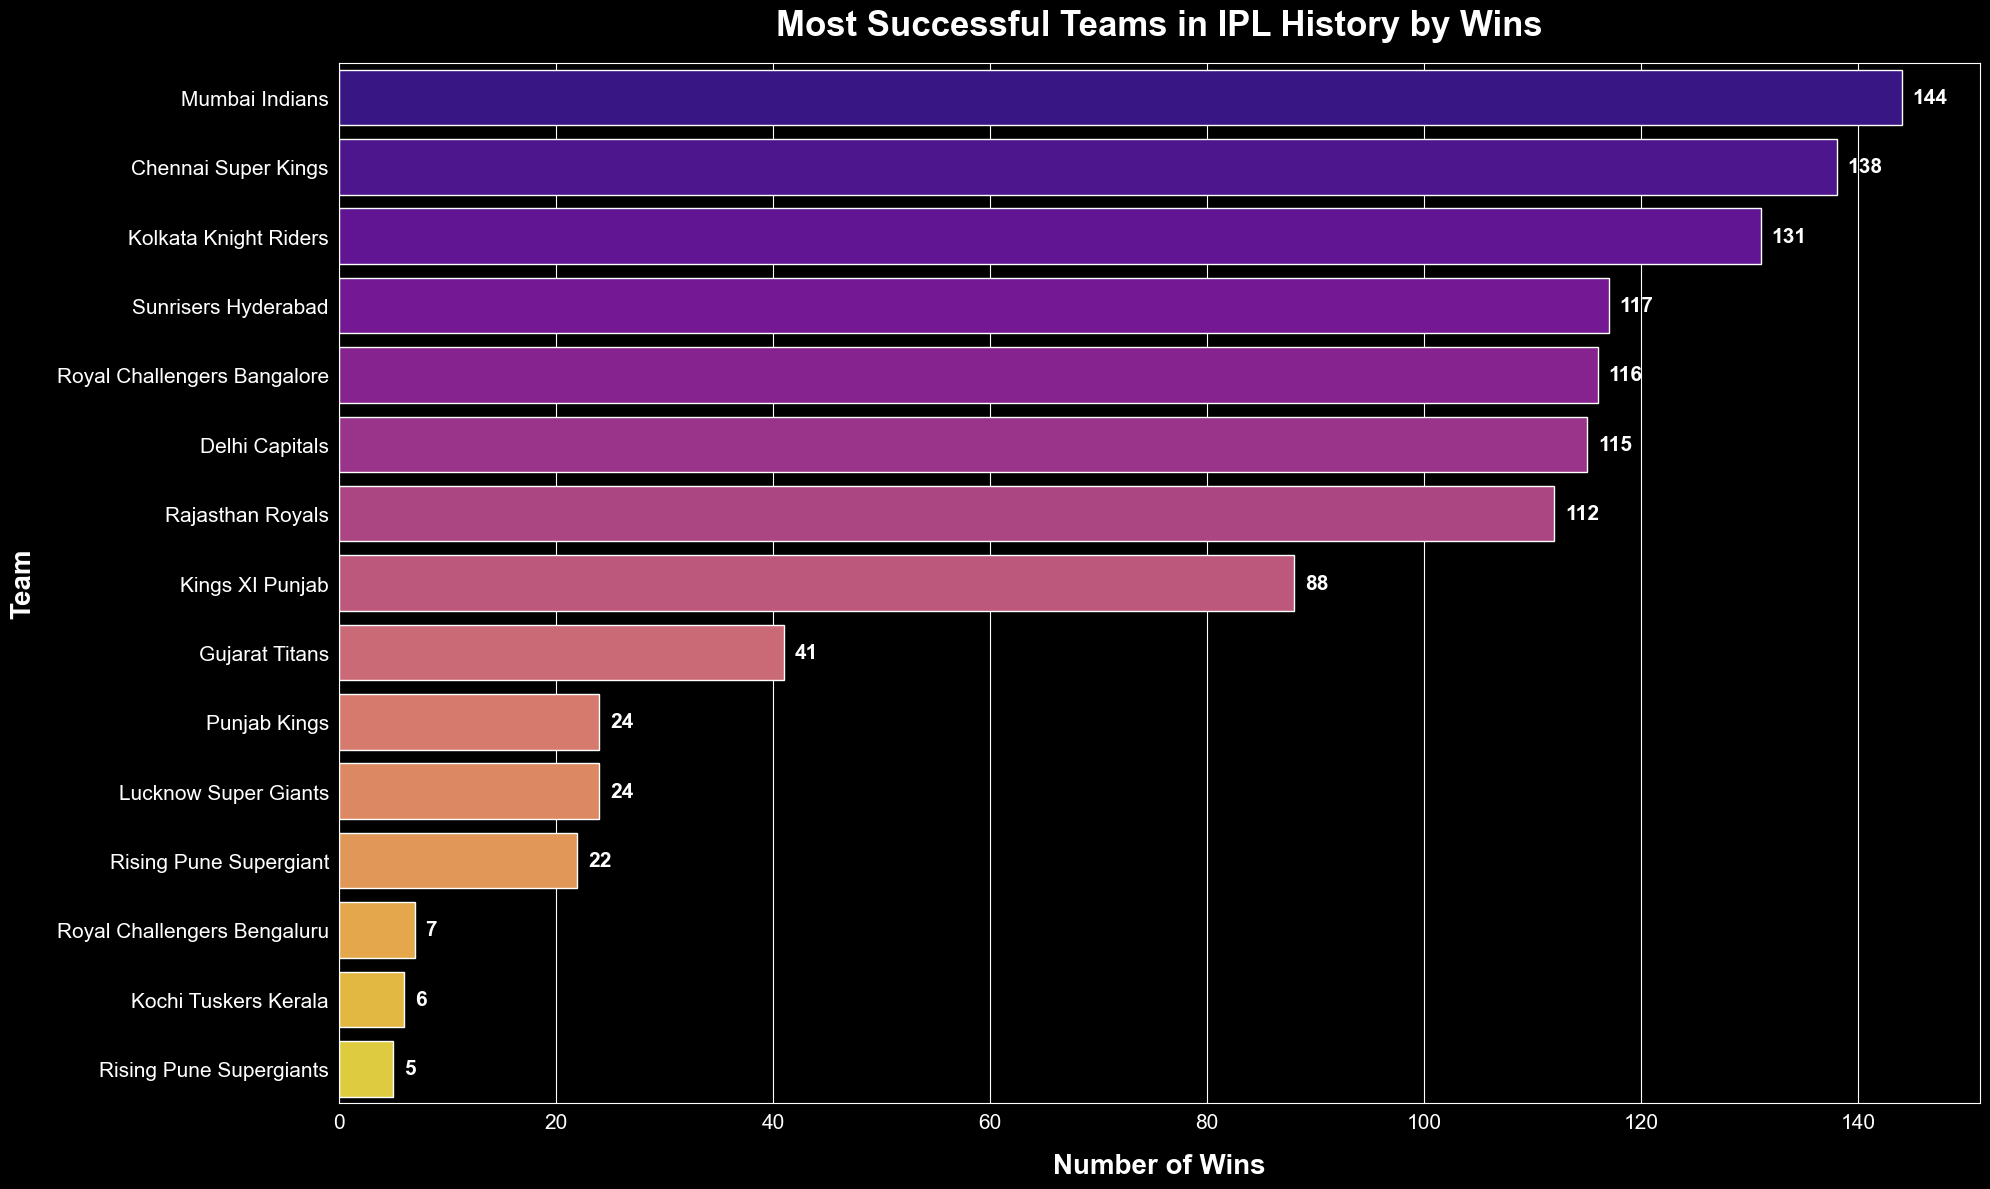

In [52]:
# Create a horizontal bar chart showing the most successful teams by number of wins
# This visualization highlights the dominance of certain teams in IPL history

fig, ax = plt.subplots(figsize=(20, 12))  # Create a new figure and axis for the plot
team_wins = matches_df['winner'].value_counts()  # Count wins per team
sns.barplot(x=team_wins.values, y=team_wins.index, ax=ax, palette='plasma', orient='h')  # Create the horizontal bar plot
ax.set_title('Most Successful Teams in IPL History by Wins', fontsize=25, pad=20, weight='bold')  # Set the title with custom font size and padding
ax.set_xlabel('Number of Wins', fontsize=20, labelpad=15, weight='bold')  # Set the x-axis label with custom font size and padding
ax.set_ylabel('Team', fontsize=20, labelpad=15, weight='bold')  # Set the y-axis label with custom font size and padding
ax.tick_params(axis='both', which='major', labelsize=15)  # Set tick parameters for better readability


# Annotate each bar with the exact number of wins
for i, v in enumerate(team_wins.values): # Loop through each bar
    ax.text(v + 1, i, str(v), color='white', va='center', fontsize=15, weight='bold') # Position the text at the end of each bar


plt.tight_layout()  # Adjust layout to prevent clipping of labels

plt.savefig(os.path.join(viz_dir, '02_team_wins.png')) # Save the figure with the specified path

plt.show()  # Display the plot

## **--- 5.3 : Toss Decision Percentage (Donut Pie Chart) ---**

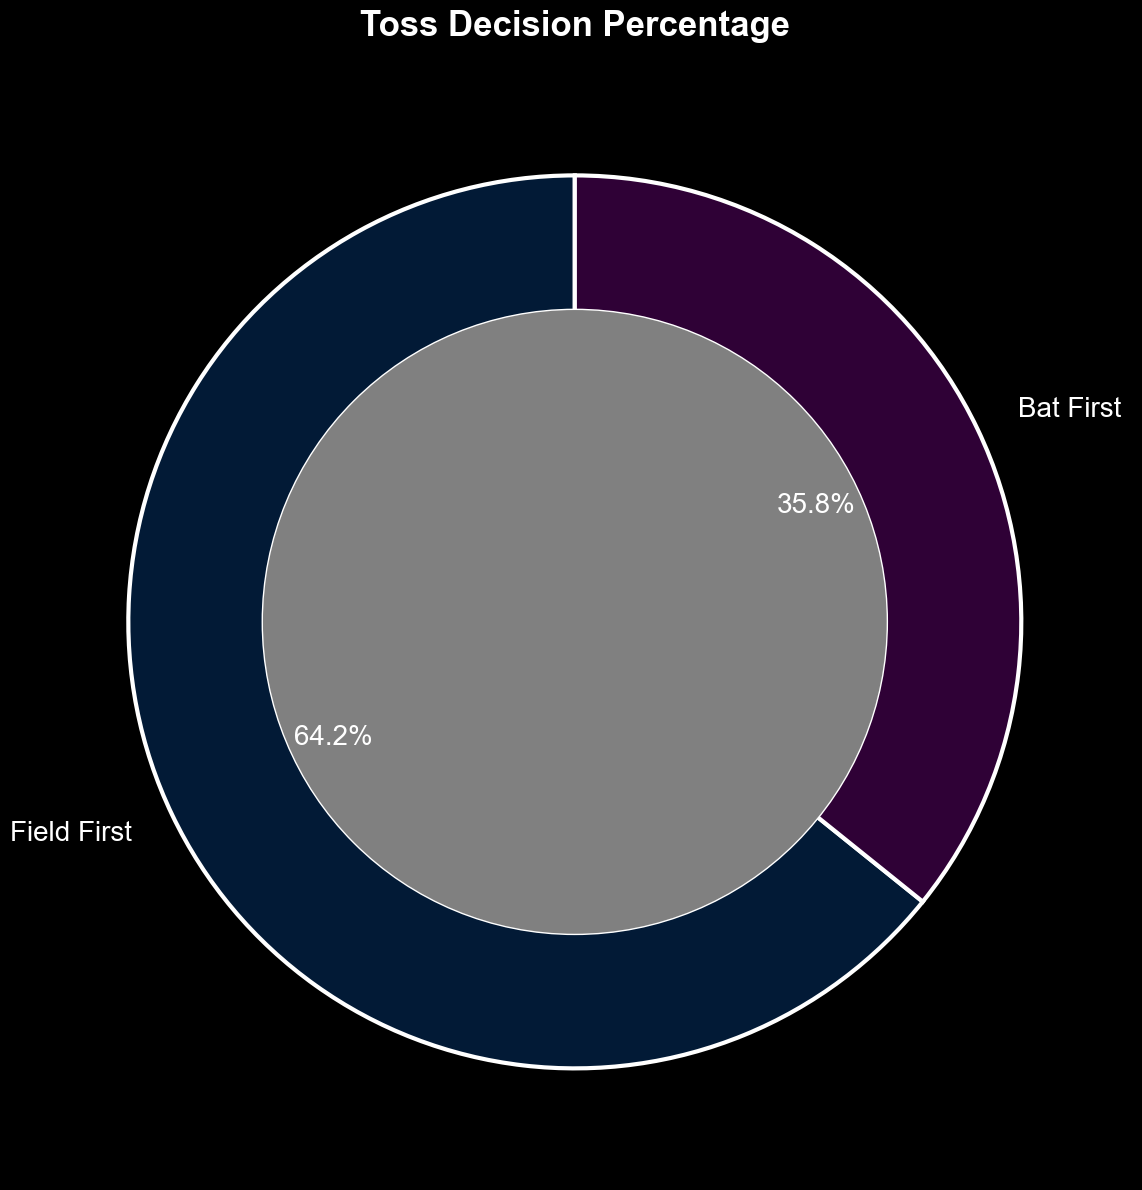

In [53]:
# Create a donut pie chart showing the percentage of toss decisions (bat or field)
# This visualization highlights the strategic choices made by teams after winning the toss

fig, ax = plt.subplots(figsize=(20, 12))  # Create a new figure and axis for the plot
toss_decisions = matches_df['toss_decision'].value_counts()  # Count the number of each toss decision
ax.pie(toss_decisions, labels=['Field First', 'Bat First'], autopct='%1.1f%%', startangle=90,
       colors=["#032347C5","#3A0243D1"], wedgeprops={'edgecolor': 'white', 'linewidth': 3},
       textprops={'fontsize': 20})  # Create the pie chart with customizations


# Create a circle for the center of the plot to make it a donut chart
centre_circle = plt.Circle((0,0),0.70,fc='gray')  # Create the center circle with gray fill
fig.gca().add_artist(centre_circle)  # Add the center circle to the pie chart
ax.set_title('Toss Decision Percentage', fontsize=25, pad=20, weight='bold')  # Set the title with custom font size and padding


plt.tight_layout()  # Adjust layout to prevent clipping of labels

plt.savefig(os.path.join(viz_dir, '03_toss_decision.png'))  # Save the figure to the specified path

plt.show()  # Display the plot

## **--- 5.4 : Impact of Toss on Match Outcome (Grouped Bar Chart) ---**

C:\Users\Sahil Kesharwani\AppData\Local\Temp\ipykernel_20296\3484923198.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='toss_decision', y='win_percentage', data=toss_impact, ax=ax, palette='coolwarm', order=['bat', 'field'])  # Create the bar plot with custom order


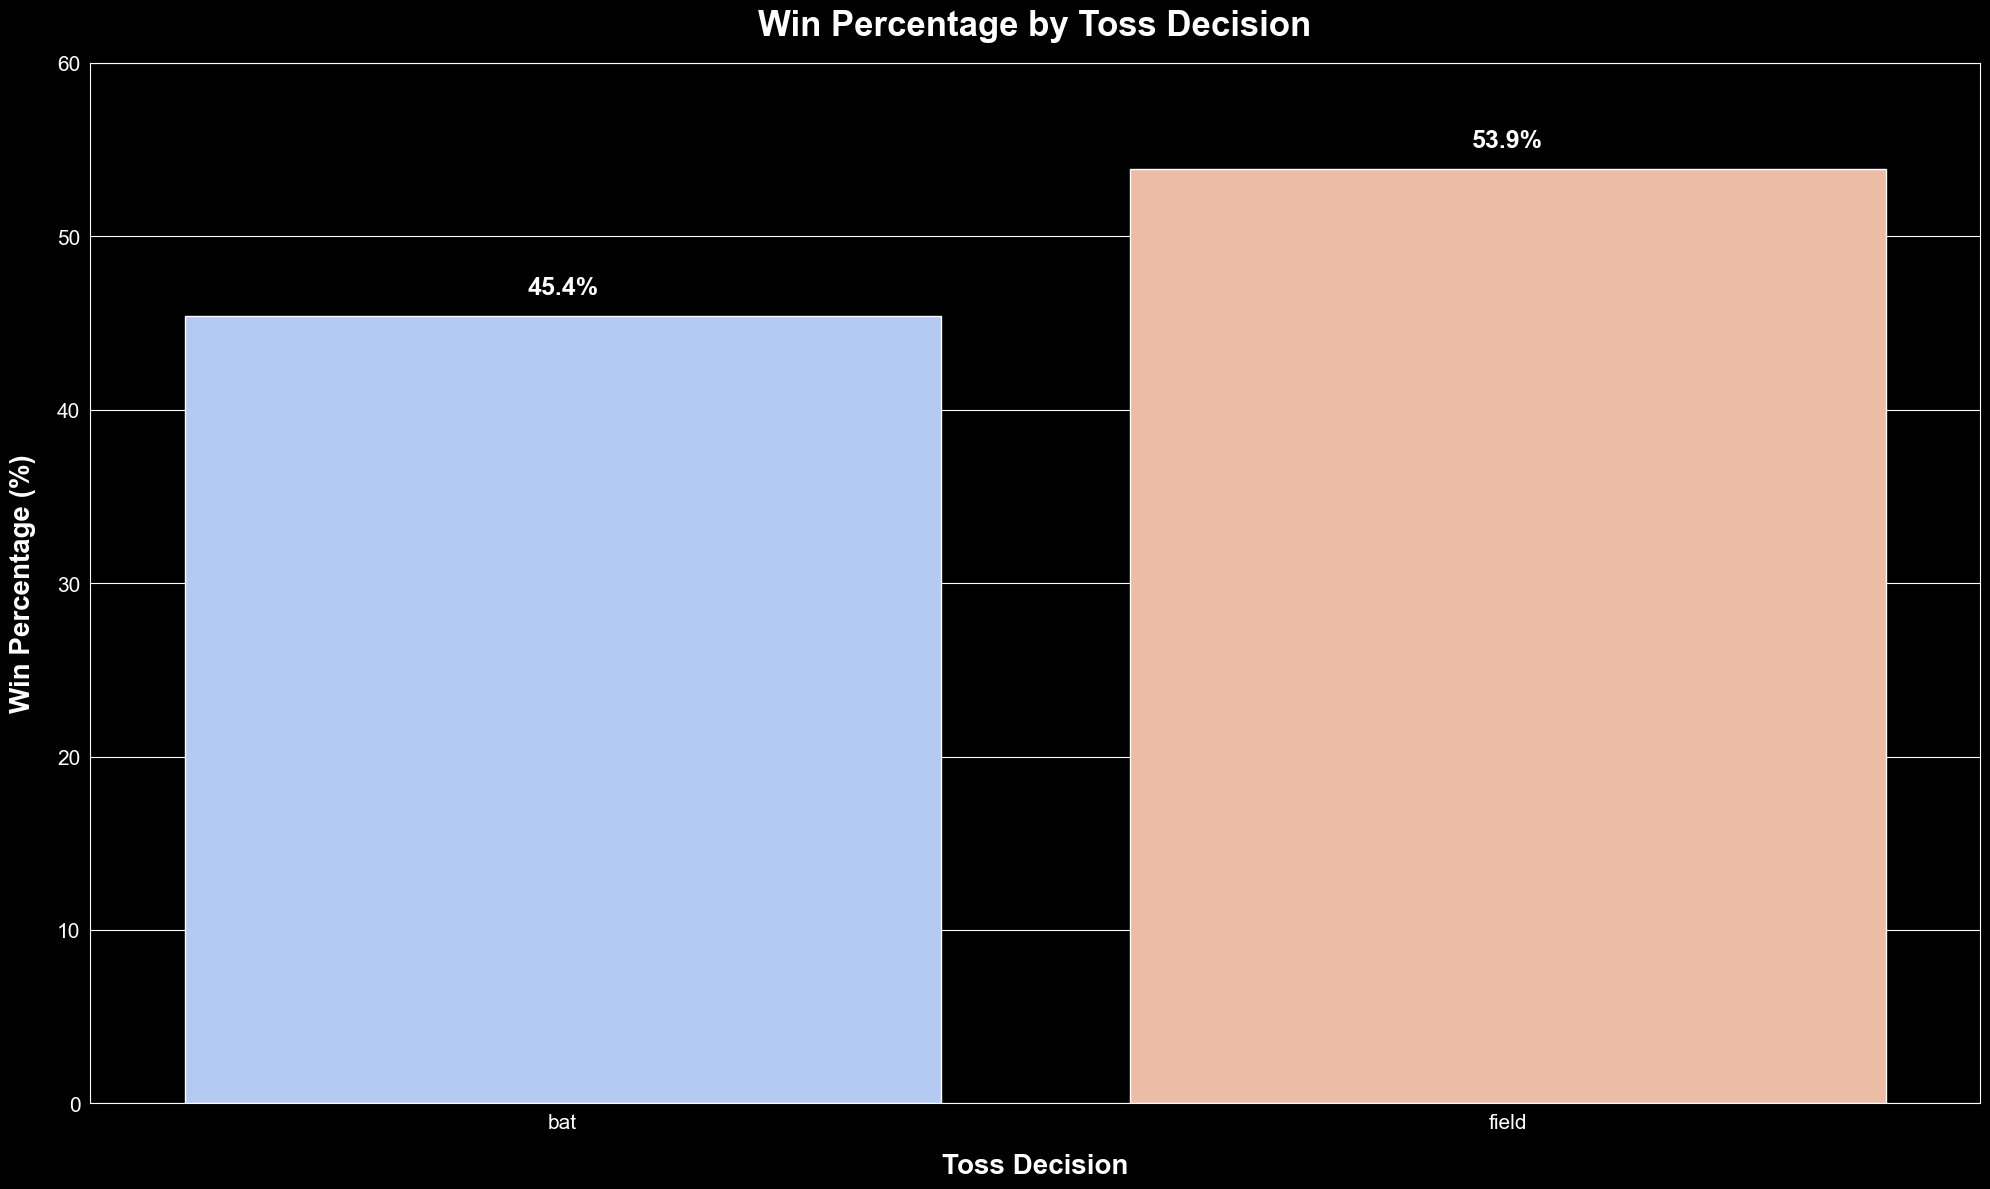

In [54]:
# Create a bar chart showing the impact of toss decision on match outcome
# This visualization highlights whether choosing to bat or field after winning the toss affects match results


# Calculate how often the team winning the toss also wins the match, broken down by their toss decision (bat or field)
toss_win_decision = matches_df.groupby('toss_decision')['winner'].apply(lambda x: (x == matches_df.loc[x.index, 'toss_winner']).sum()).reset_index(name='toss_and_match_winner')  # Count how many times the toss winner also won the match, grouped by toss decision
total_by_decision = matches_df['toss_decision'].value_counts().reset_index()  # Count total matches for each toss decision
total_by_decision.columns = ['toss_decision', 'total_matches']  # Rename columns for clarity
toss_impact = pd.merge(toss_win_decision, total_by_decision, on='toss_decision')  # Merge the two DataFrames on 'toss_decision'
toss_impact['win_percentage'] = (toss_impact['toss_and_match_winner'] / toss_impact['total_matches']) * 100  # Calculate win percentage


# Create a bar chart
fig, ax = plt.subplots(figsize=(20, 12))  # Create a new figure and axis for the plot
sns.barplot(x='toss_decision', y='win_percentage', data=toss_impact, ax=ax, palette='coolwarm', order=['bat', 'field'])  # Create the bar plot with custom order
ax.set_title('Win Percentage by Toss Decision', fontsize=25, pad=20, weight='bold')  # Set the title with custom font size and padding
ax.set_xlabel('Toss Decision', fontsize=20, labelpad=15, weight='bold')  # Set the x-axis label with custom font size and padding
ax.set_ylabel('Win Percentage (%)', fontsize=20, labelpad=15, weight='bold')  # Set the y-axis label with custom font size and padding
ax.tick_params(axis='both', which='major', labelsize=15)  # Set tick parameters for better readability
ax.set_ylim(0, 60)  # Set y-axis limits for better visualization


# Annotate each bar with the exact win percentage
for i in ax.patches: # Loop through each bar in the bar plot
    ax.text(i.get_x() + i.get_width() / 2, i.get_height() + 1, f"{i.get_height():.1f}%",
            fontsize=18, color='white', ha='center', weight='bold', va='bottom') # Position the text above each bar


plt.tight_layout() # Adjust layout to prevent clipping of labels

plt.savefig(os.path.join(viz_dir, '04_toss_impact.png'))  # Save the figure to the specified path

plt.show()  # Display the plot

## **--- 5.5 : Top 10 'Player of the Match' Winners (Horizontal Bar Chart) ---**

C:\Users\Sahil Kesharwani\AppData\Local\Temp\ipykernel_20296\3536432813.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_potm.values, y=top_potm.index, ax=ax, palette='magma', orient='h')  # Create the horizontal bar plot


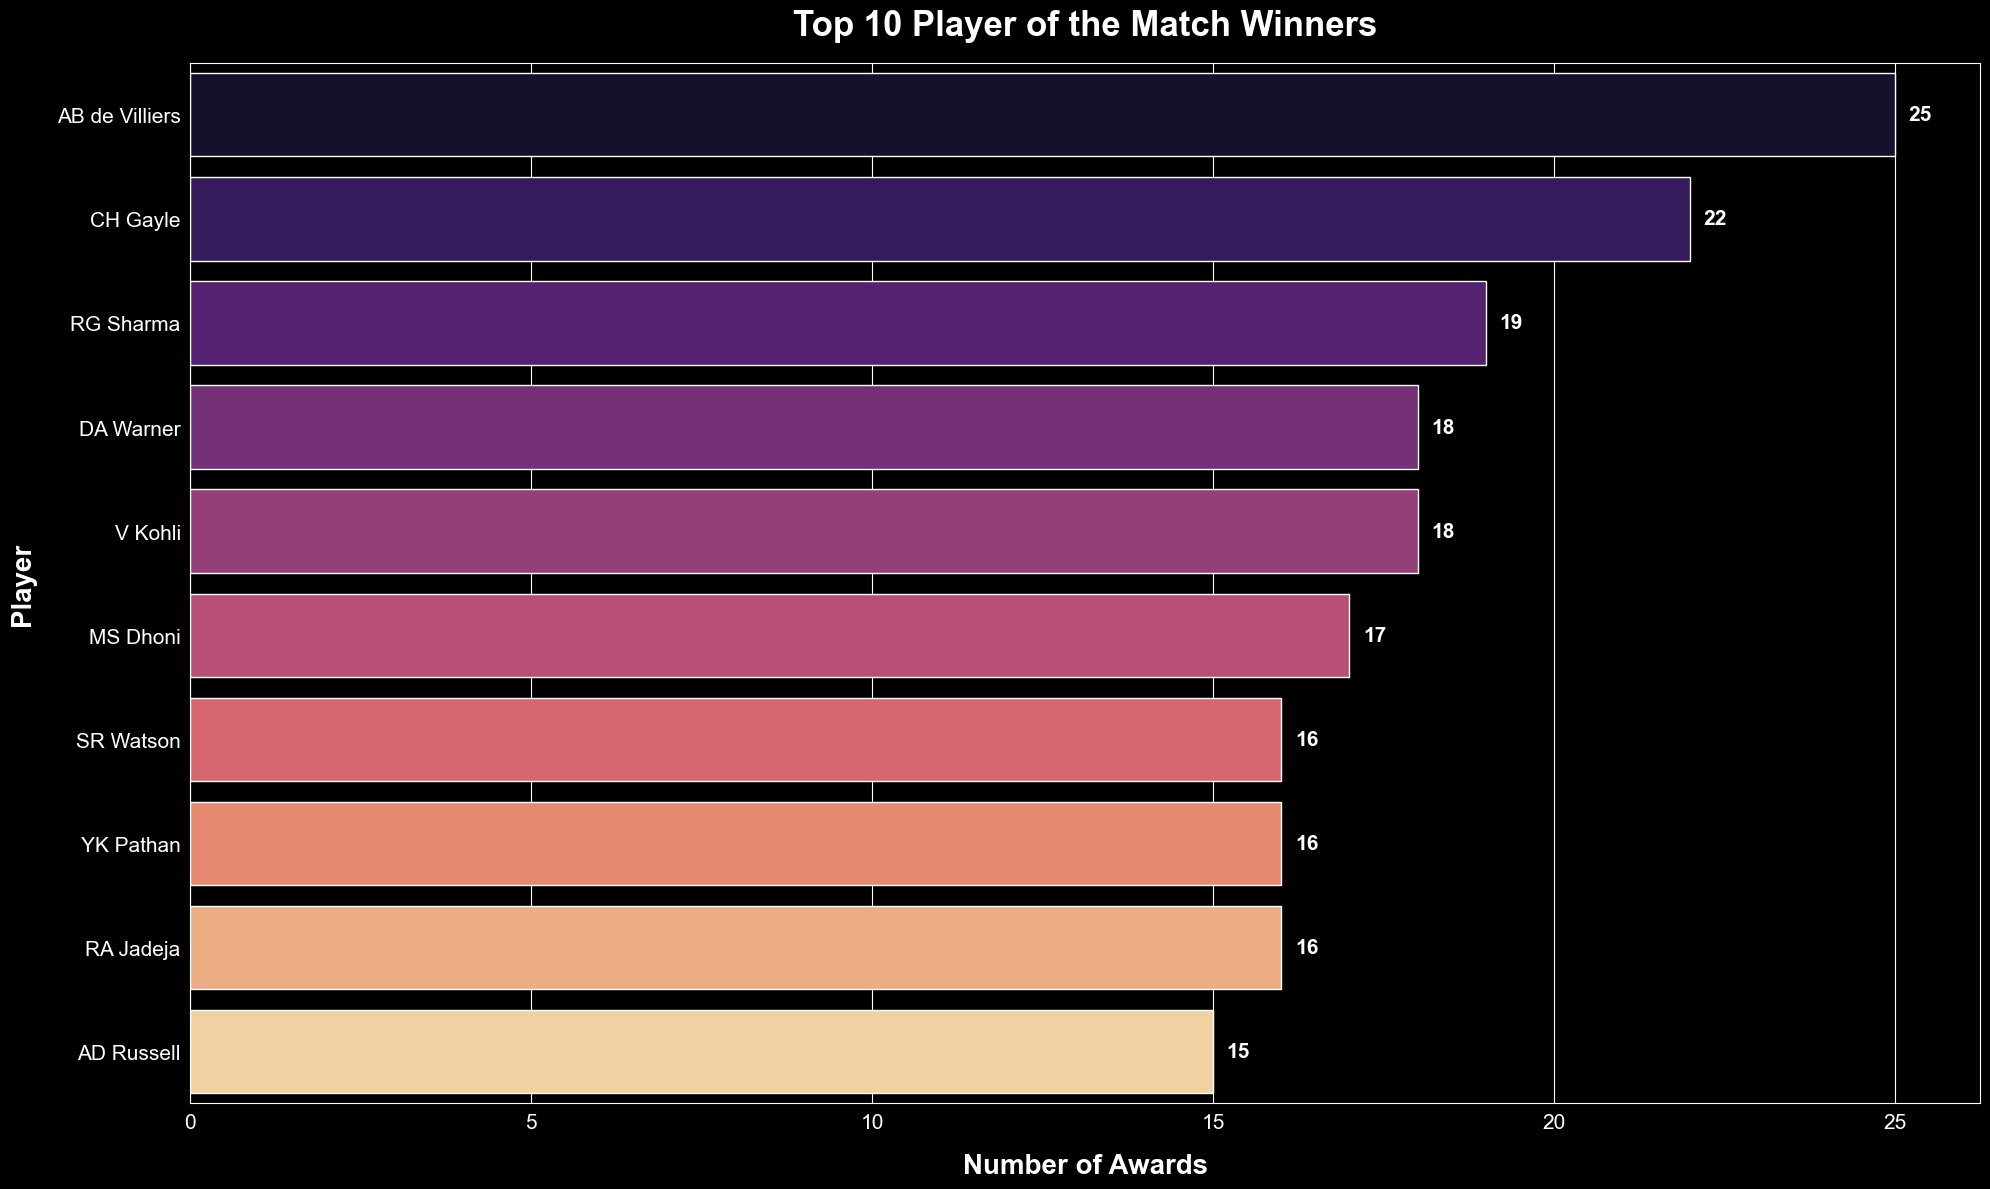

In [55]:
# Create a horizontal bar chart showing the top 10 'Player of the Match' winners
# This visualization highlights the standout players in IPL history

fig, ax = plt.subplots(figsize=(20, 12))  # Create a new figure and axis for the plot
top_potm = matches_df['player_of_match'].value_counts().head(10)  # Get the top 10 players with the most 'Player of the Match' awards
sns.barplot(x=top_potm.values, y=top_potm.index, ax=ax, palette='magma', orient='h')  # Create the horizontal bar plot
ax.set_title('Top 10 Player of the Match Winners', fontsize=25, pad=20, weight='bold')  # Set the title with custom font size and padding
ax.set_xlabel('Number of Awards', fontsize=20, labelpad=15, weight='bold')  # Set the x-axis label with custom font size and padding
ax.set_ylabel('Player', fontsize=20, labelpad=15, weight='bold')  # Set the y-axis label with custom font size and padding
ax.tick_params(axis='both', which='major', labelsize=15)  # Set tick parameters for better readability


# Annotate each bar with the exact number of awards
for i, v in enumerate(top_potm.values): # Loop through each bar
    ax.text(v + 0.2, i, str(v), color='white', va='center', fontsize=15, weight='bold') # Position the text at the end of each bar


plt.tight_layout()  # Adjust layout to prevent clipping of labels

plt.savefig(os.path.join(viz_dir, '05_top_potm.png'))  # Save the figure with the specified path

plt.show()  # Display the plot

## **--- 5.6 : Top 10 Run Scorers (Horizontal Bar Chart) ---**

C:\Users\Sahil Kesharwani\AppData\Local\Temp\ipykernel_20296\3255660489.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_scorers_10.values, y=top_scorers_10.index, ax=ax, palette='cividis', orient='h', edgecolor='white')  # Create the horizontal bar plot with edge color


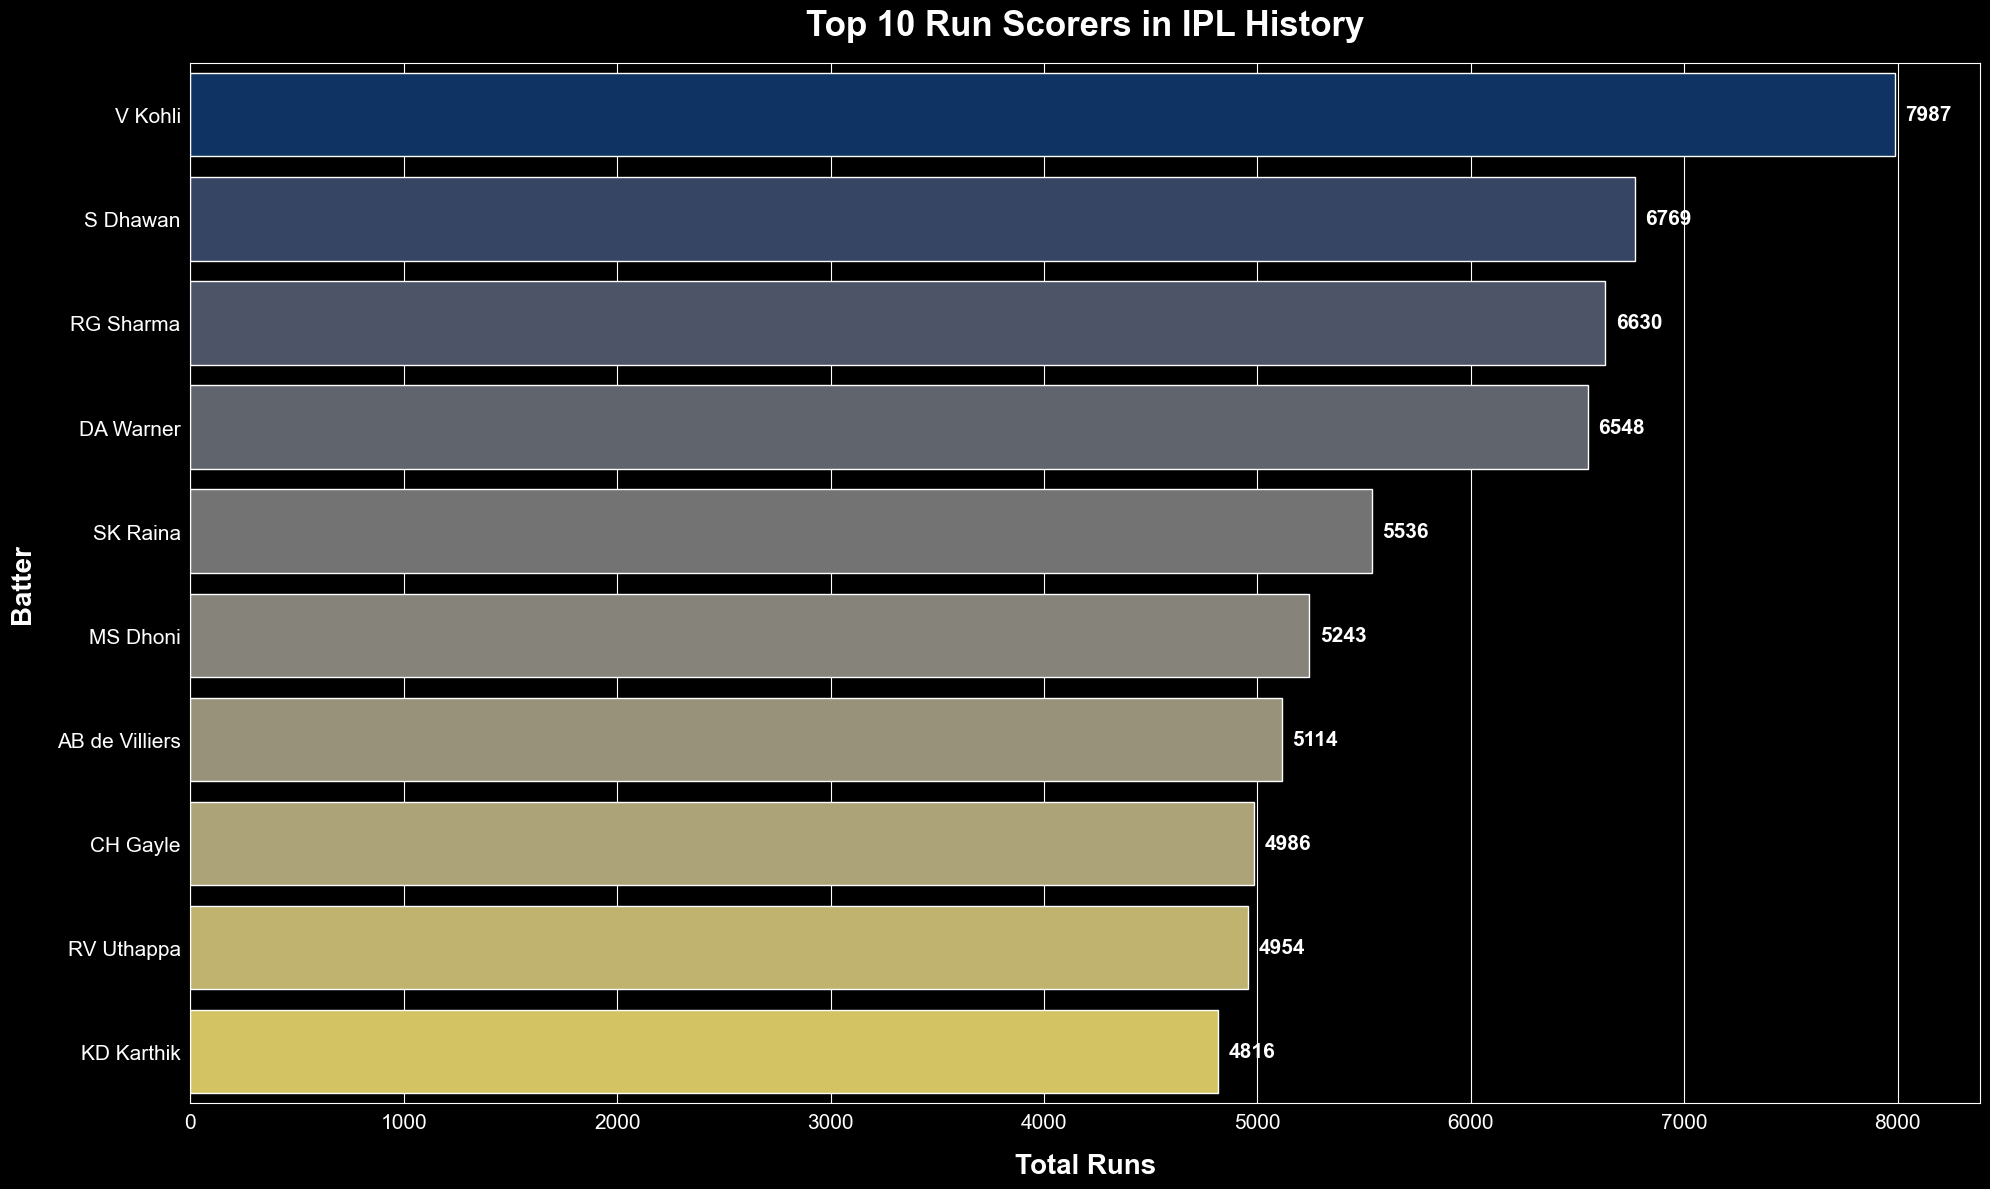

In [56]:
# Create a horizontal bar chart showing the top 10 run scorers in IPL history
# This visualization highlights the most prolific batsmen in IPL history

fig, ax = plt.subplots(figsize=(20, 12))  # Create a new figure and axis for the plot
top_scorers_10 = merged_df.groupby('batter')['batsman_runs'].sum().sort_values(ascending=False).head(10)  # Get the top 10 run scorers
sns.barplot(x=top_scorers_10.values, y=top_scorers_10.index, ax=ax, palette='cividis', orient='h', edgecolor='white')  # Create the horizontal bar plot with edge color
ax.set_title('Top 10 Run Scorers in IPL History', fontsize=25, pad=20, weight='bold', color='white')  # Set the title with custom font size and padding
ax.set_xlabel('Total Runs', fontsize=20, labelpad=15, weight='bold', color='white')  # Set the x-axis label with custom font size and padding
ax.set_ylabel('Batter', fontsize=20, labelpad=15, weight='bold', color='white')  # Set the y-axis label with custom font size and padding
ax.tick_params(axis='both', which='major', labelsize=15, colors='white')  # Set tick parameters for better readability


# Annotate each bar with the exact number of runs
for i, v in enumerate(top_scorers_10.values):  # Loop through each bar
    ax.text(v + 50, i, str(v), color='white', va='center', fontsize=15, weight='bold')  # Position the text at the end of each bar


plt.tight_layout() # Adjust layout to prevent clipping of labels

plt.savefig(os.path.join(viz_dir, '06_top_scorers.png')) # Save the figure with the specified path

plt.show()  # Display the plot

## **--- 5.7 : Top 10 Wicket Takers (Horizontal Bar Chart) ---**

C:\Users\Sahil Kesharwani\AppData\Local\Temp\ipykernel_20296\514505291.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_bowlers_10.values, y=top_bowlers_10.index, ax=ax, palette='rocket', orient='h', edgecolor='white', linewidth=1.5)  # Create the horizontal bar plot with edge color and line width


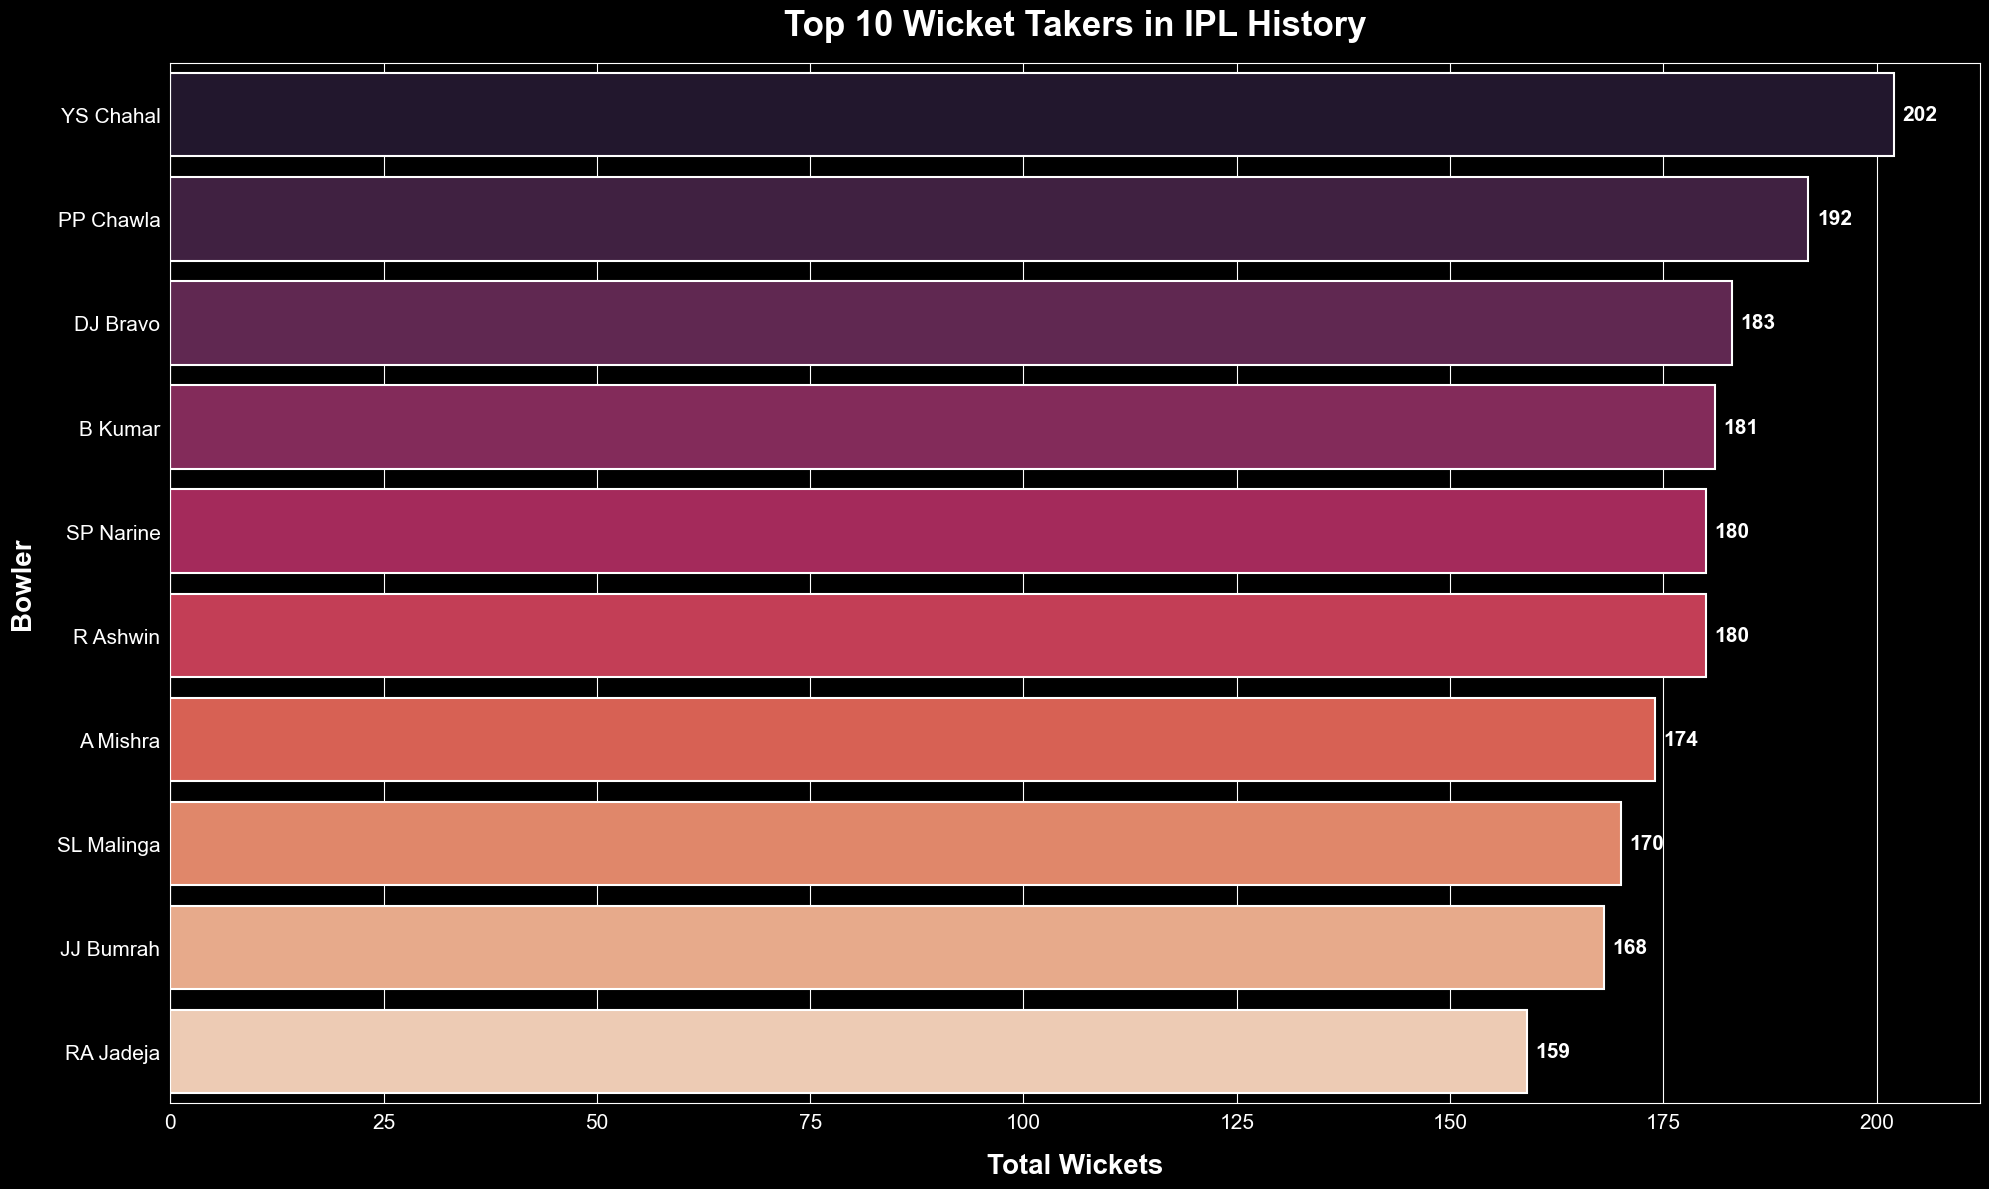

In [57]:
# Create a horizontal bar chart showing the top 10 wicket takers in IPL history
# This visualization highlights the most successful bowlers in IPL history

fig, ax = plt.subplots(figsize=(20, 12))    # Create a new figure and axis for the plot

# Wicket calculation is needed here if you run cells independently
wicket_types_to_exclude = ['run out', 'retired hurt', 'obstructing the field']  # Exclude non-bowler wicket types
wickets = merged_df[~merged_df['dismissal_kind'].isin(wicket_types_to_exclude) & (merged_df['is_wicket'] == 1)] # Filter for valid bowler wickets
top_bowlers_10 = wickets.groupby('bowler')['is_wicket'].sum().sort_values(ascending=False).head(10) # Get the top 10 wicket takers
sns.barplot(x=top_bowlers_10.values, y=top_bowlers_10.index, ax=ax, palette='rocket', orient='h', edgecolor='white', linewidth=1.5)  # Create the horizontal bar plot with edge color and line width
ax.set_title('Top 10 Wicket Takers in IPL History', fontsize=25, pad=20, weight='bold', color='white')  # Set the title with custom font size and padding
ax.set_xlabel('Total Wickets', fontsize=20, labelpad=15, weight='bold', color='white')  # Set the x-axis label with custom font size and padding
ax.set_ylabel('Bowler', fontsize=20, labelpad=15, weight='bold', color='white')  # Set the y-axis label with custom font size and padding
ax.tick_params(axis='both', which='major', labelsize=15, colors='white')  # Set tick parameters for better readability


# Annotate each bar with the exact number of wickets
for i, v in enumerate(top_bowlers_10.values):  # Loop through each bar
    ax.text(v + 1, i, str(v), color='white', va='center', fontsize=15, weight='bold')  # Position the text at the end of each bar


plt.tight_layout()  # Adjust layout to prevent clipping of labels

plt.savefig(os.path.join(viz_dir, '07_top_bowlers.png'))

plt.show()  # Display the plot

## **--- 5.8 : Wins per Team per Season (Heatmap) ---**

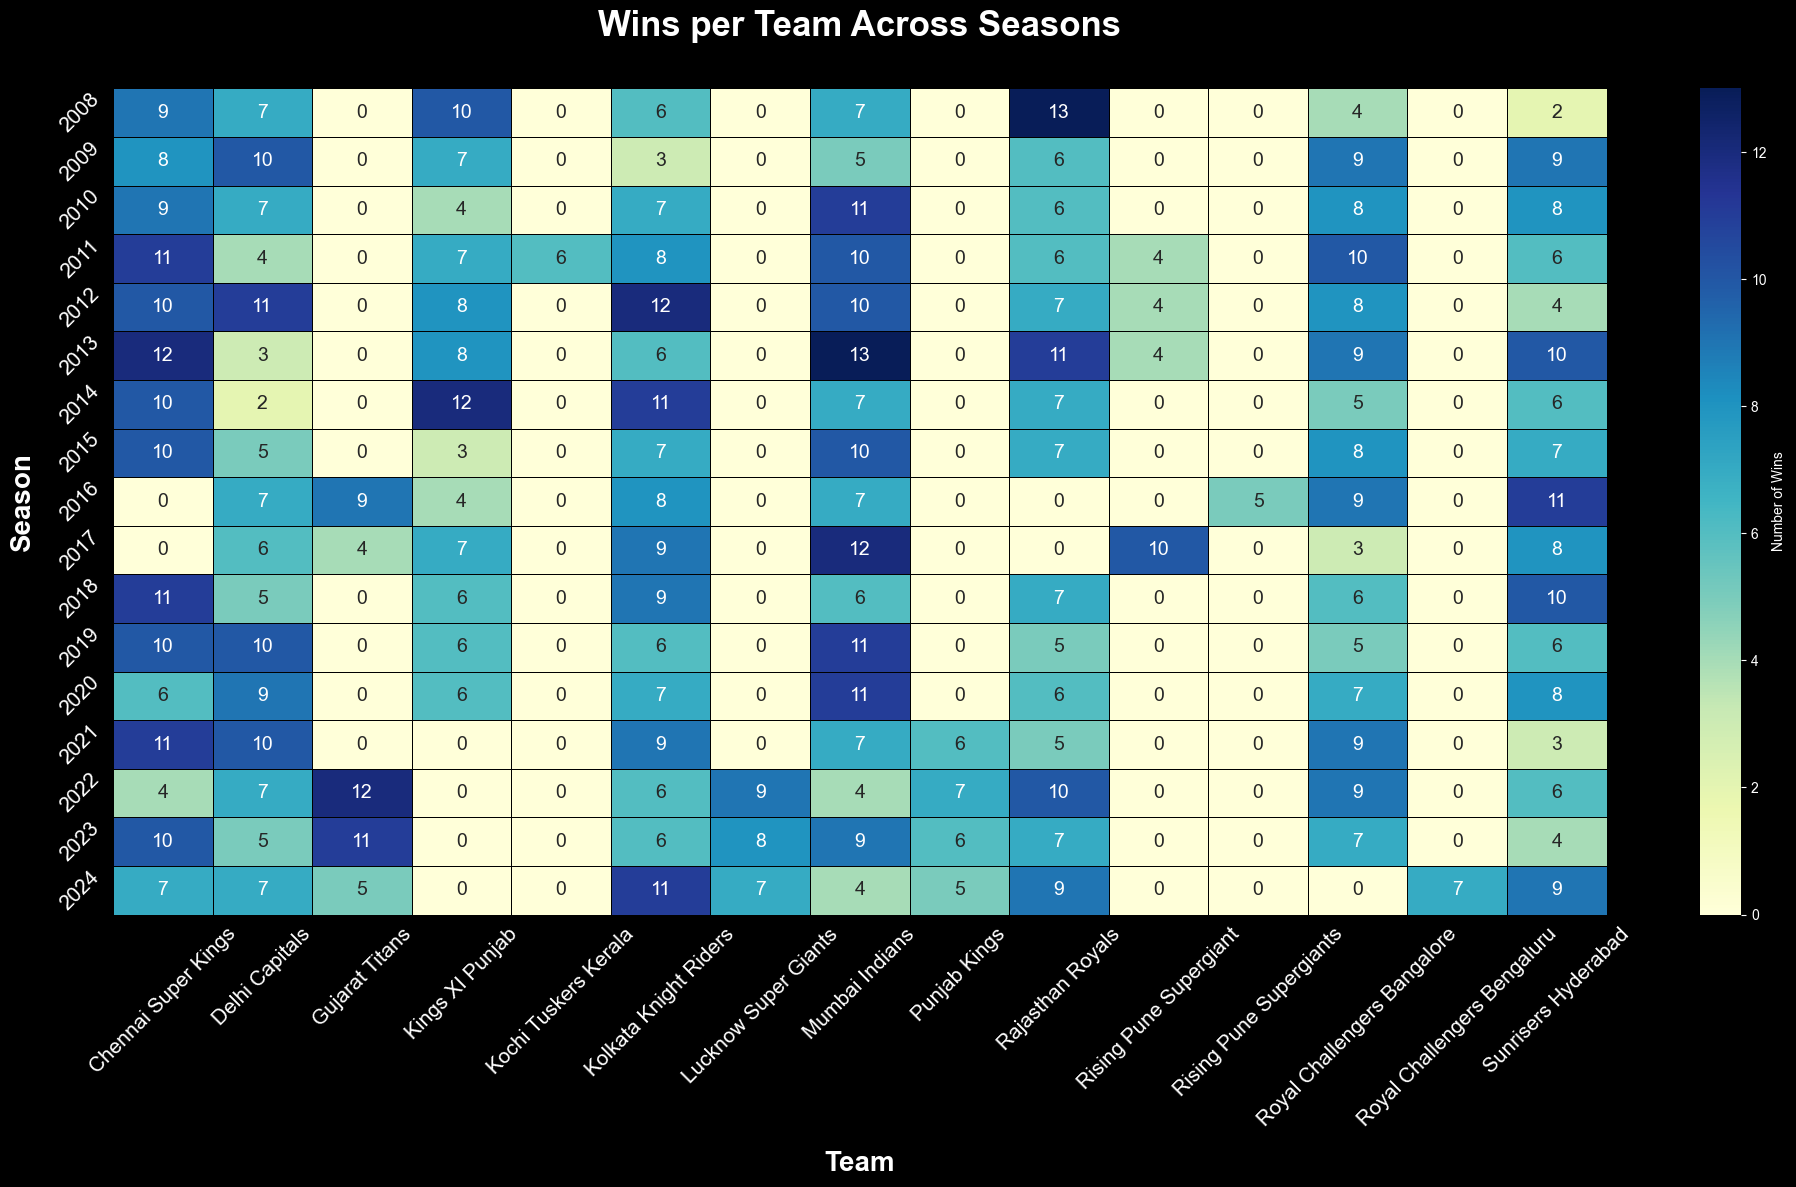

In [59]:
# Create a heatmap showing the number of wins per team across different seasons
# This visualization helps identify dominant teams in specific seasons

# Prepare the data for the heatmap
# Create a pivot table of wins by season and team
# Fill NaN values with 0 and convert to integer for clarity
wins_by_season = matches_df.groupby('season')['winner'].value_counts().unstack().fillna(0).astype(int)
# Create the heatmap
fig, ax = plt.subplots(figsize=(20, 12))  # Create a new figure and axis for the plot
sns.heatmap(wins_by_season, annot=True, fmt='d', cmap='YlGnBu', ax=ax, linewidths=.5, annot_kws={"size": 14}, cbar_kws={'label': 'Number of Wins'}, linecolor='black')  # Create the heatmap with annotations and customizations
ax.set_title('Wins per Team Across Seasons', fontsize=25, pad=20, weight='bold', color='white', y=1.03)  # Set the title with custom font size and padding
ax.set_xlabel('Team', fontsize=20, color='white', labelpad=15, weight='bold')  # Set the x-axis label with custom font size and padding
ax.set_ylabel('Season', fontsize=20, color='white', labelpad=15, weight='bold')  # Set the y-axis label with custom font size and padding
ax.tick_params(axis='both', which='major', labelsize=15, colors='white', rotation=45, labelrotation=45, labelbottom=True)  # Set tick parameters for better readability


plt.tight_layout()  # Adjust layout to prevent clipping of labels

plt.savefig(os.path.join(viz_dir, '08_wins_heatmap.png'))   # Save the figure with the specified path

plt.show()  # Display the plot

## **--- 5.9 : Comparison of Wins by Batting First vs. Fielding First (Stacked Bar Chart) ---**

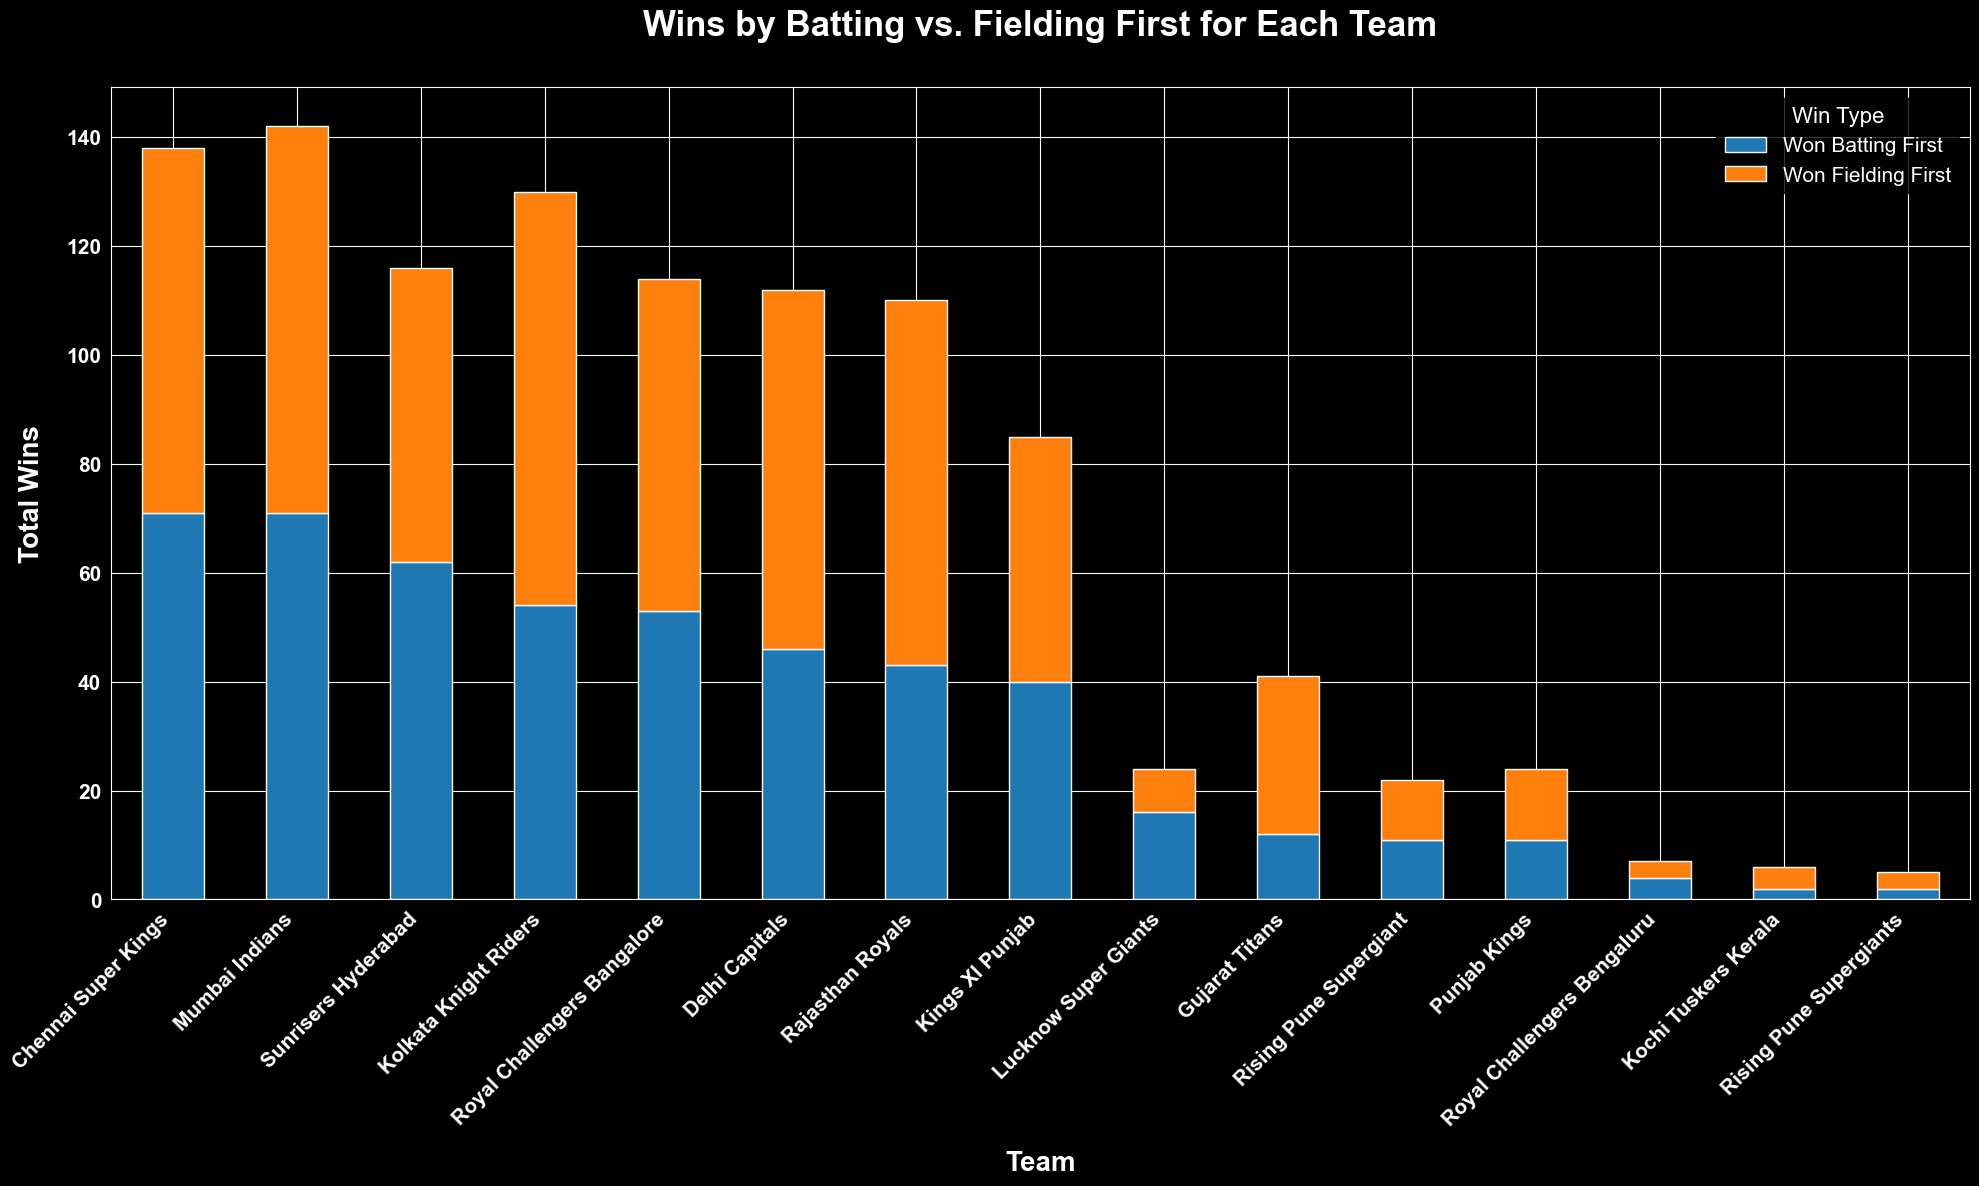

In [60]:
# Create a stacked bar chart showing wins by batting first vs. fielding first for each team
# We determine if a team won by batting first (by runs) or fielding first (by wickets)
# This visualization helps understand team strengths in different match scenarios

# Prepare the data
matches_df['won_by_batting_first'] = (matches_df['result'] == 'runs')   # Create a column indicating wins by batting first
matches_df['won_by_fielding_first'] = (matches_df['result'] == 'wickets')   # Create a column indicating wins by fielding first
wins_by_choice = matches_df.groupby('winner')[['won_by_batting_first', 'won_by_fielding_first']].sum()  # Group by team and sum the win columns
wins_by_choice = wins_by_choice.sort_values('won_by_batting_first', ascending=False)    # Sort teams by wins from batting first


# Create the stacked bar chart
fig, ax = plt.subplots(figsize=(20, 12))    # Create a new figure and axis for the plot
wins_by_choice.plot(kind='bar', stacked=True, ax=ax, color=['#1f77b4', '#ff7f0e'])  # Create the stacked bar plot with custom colors
ax.set_title('Wins by Batting vs. Fielding First for Each Team', fontsize=25, pad=20, weight='bold', color='white', y=1.03)  # Set the title with custom font size and padding
ax.set_xlabel('Team', fontsize=20, color='white', labelpad=15, weight='bold')  # Set the x-axis label with custom font size and padding
ax.set_ylabel('Total Wins', fontsize=20, color='white', labelpad=15, weight='bold')  # Set the y-axis label with custom font size and padding
ax.tick_params(axis='both', which='major', labelsize=15, colors='white', rotation=45, labelrotation=45, labelbottom=True)  # Set tick parameters for better readability 
ax.legend(['Won Batting First', 'Won Fielding First'], fontsize=15, title='Win Type', title_fontsize='16', loc='upper right', frameon=True, edgecolor='black')  # Customize the legend
plt.xticks(rotation=45, ha='right', fontsize=15, weight='bold', color='white')  # Rotate x-ticks for better readability
plt.yticks(fontsize=15, weight='bold', color='white', rotation=0, ha='right')  # Customize y-ticks for better readability


plt.tight_layout()  # Adjust layout to prevent clipping of labels

plt.savefig(os.path.join(viz_dir, '09_wins_by_choice.png'))  # Save the figure with the specified path

plt.show()  # Display the plot

## **--- 5.10 : Top 10 Most Frequent Venues (Bar Chart) ---**

C:\Users\Sahil Kesharwani\AppData\Local\Temp\ipykernel_20296\781842141.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_venues_10.values, y=top_venues_10.index, ax=ax, palette='cubehelix', orient='h', edgecolor='white', linewidth=1.5)  # Create the horizontal bar plot with edge color and line width


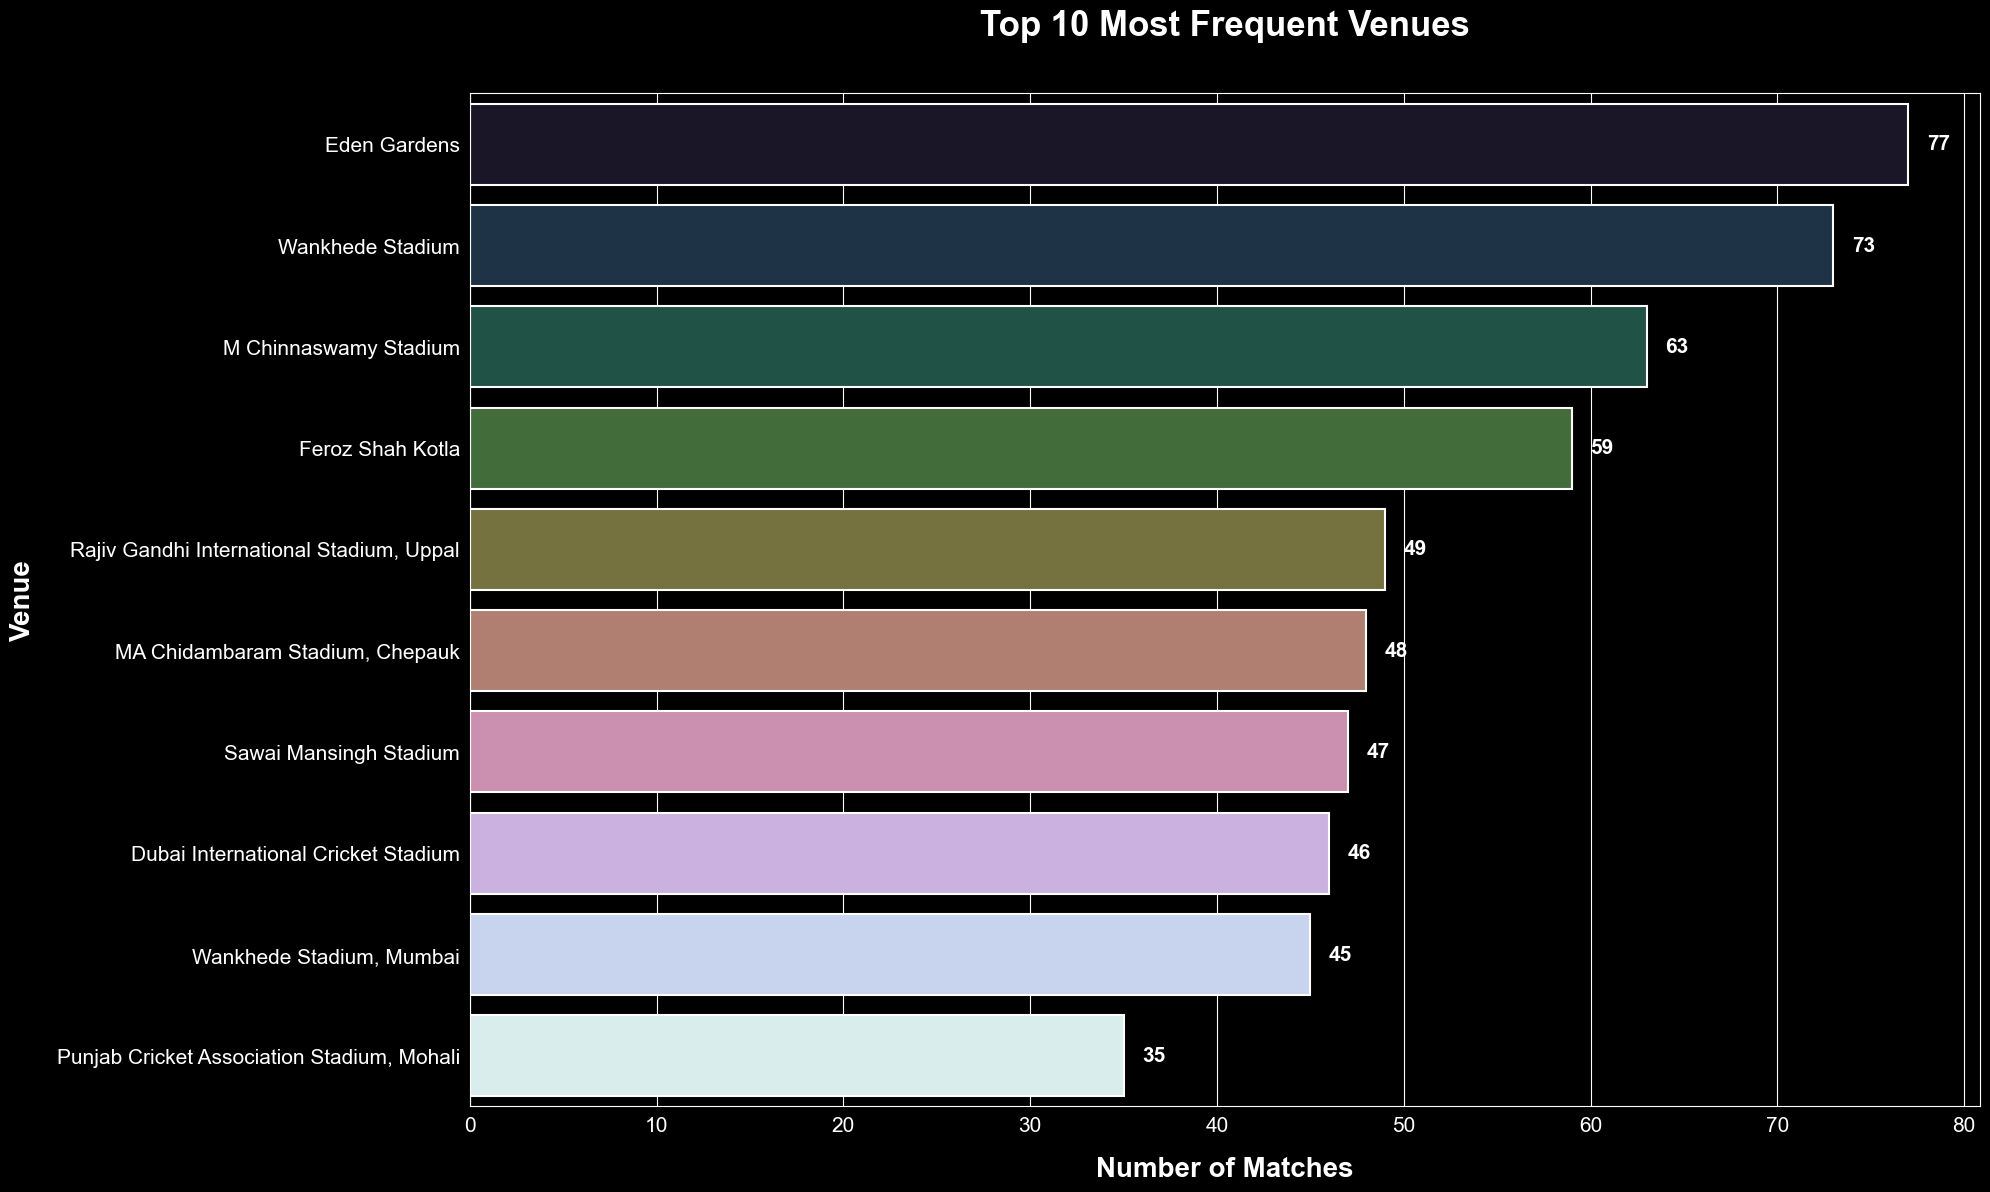

In [61]:
# Create a horizontal bar chart showing the top 10 venues by number of matches played
# This visualization highlights the most popular venues in IPL history

fig, ax = plt.subplots(figsize=(20, 12))    # Create a new figure and axis for the plot
top_venues_10 = matches_df['venue'].value_counts().head(10) # Get the top 10 venues by number of matches played
sns.barplot(x=top_venues_10.values, y=top_venues_10.index, ax=ax, palette='cubehelix', orient='h', edgecolor='white', linewidth=1.5)  # Create the horizontal bar plot with edge color and line width
ax.set_title('Top 10 Most Frequent Venues', fontsize=25, pad=20, weight='bold', color='white', y=1.03)  # Set the title with custom font size and padding
ax.set_xlabel('Number of Matches', fontsize=20, labelpad=15, weight='bold', color='white')  # Set the x-axis label with custom font size and padding
ax.set_ylabel('Venue', fontsize=20, labelpad=15, weight='bold', color='white')  # Set the y-axis label with custom font size and padding
ax.tick_params(axis='both', which='major', labelsize=15, colors='white', rotation=0, labelrotation=0, labelbottom=True)  # Set tick parameters for better readability


# Annotate each bar with the exact number of matches
for i, v in enumerate(top_venues_10.values):  # Loop through each bar
    ax.text(v + 1, i, str(v), color='white', va='center', fontsize=15, weight='bold')  # Position the text at the end of each bar


plt.tight_layout()  # Adjust layout to prevent clipping of labels

plt.savefig(os.path.join(viz_dir, '10_top_venues.png'))  # Save the figure with the specified path

plt.show()  # Display the plot

#
---

# **6.  Insights & Interpretation**

**Based on the exploratory analysis and visualizations, we can draw several key strategic insights into the dynamics of the Indian Premier League.**

## **Insight 1: The "Chase to Win" Strategy is Dominant and Effective.**

Our analysis (Visualization 5.3 & 5.4) shows a clear and overwhelming trend: over 61% of captains choose to field first. More importantly, this decision pays off, as teams chasing have a slightly higher win percentage. This indicates that factors like dew in the second innings and the psychological advantage of a clear target make chasing the preferred modern strategy in T20 cricket.

## **Insight 2: Dynasties are Built on a Foundation of Consistent Performers.**

The team wins chart (Visualization 5.2) and the heatmap (Visualization 5.8) clearly identify teams like **Mumbai Indians** and **Chennai Super Kings** as the league's powerhouses. This isn't random. When cross-referenced with the top player charts (Visualizations 5.5, 5.6, 5.7), we see their rosters are consistently filled with the league's most impactful performers. This demonstrates that long-term success is a direct result of retaining a core of elite, match-winning players.

## **Insight 3: High-Impact Venues Influence Outcomes.**

The venue analysis (Visualization 5.10) shows that certain grounds like **Wankhede Stadium** and **Eden Gardens** have hosted a significantly high number of matches. Teams that develop a strong home-ground advantage at these frequently used venues have a distinct edge over the season. Strategic team building should consider player suitability for home conditions.

## **Insight 4: Specialization is the Key to Individual Success.**

The lists of top run-scorers and wicket-takers (Visualizations 5.6 & 5.7) are dominated by specialist players, not all-rounders. This suggests that achieving the highest level of performance requires a dedicated focus on one discipline. For team auctions, securing the best specialist opener, death bowler, and spinner is a data-backed recipe for success.

#
---

# **7.  Report & Presentation**

## **Report**

**This Jupyter Notebook itself serves as the **final, comprehensive report**. It follows a logical structure from problem definition to conclusion, with each step of the analysis—including code, outputs, and visualizations—documented clearly.**

## **Presentation**

**Refer to `../presentations/IPL_Analysis_Presentation.pdf`**

#
---